# Phase 2: PBMC4k exploratory data analysis and clustering

This notebook explores the QC-filtered, normalized PBMC4k object produced by `01_qc_preprocessing.ipynb`. It summarizes the retained data, examines expression and technical variation, runs PCA, builds a nearest-neighbor graph, calculates a UMAP, performs Leiden clustering, and compares clusters with the **exact PBMC marker panel used in the PBMC3k notebooks**.

This is unsupervised exploration. Leiden cluster numbers are not automatically treated as cell-type labels, and this notebook does not run Harmony, XGBoost, or model retraining.

## Analysis plan

1. Load and validate the PBMC4k Phase 1 object.
2. Summarize retained cells, genes, QC distributions, and highly expressed genes.
3. Use the 2,000 genes flagged by PBMC4k Phase 1 for PCA and clustering.
4. Use the PBMC3k settings of 10 PCs, 15 neighbors, and Leiden resolution 0.5 for consistency.
5. Inspect cluster sizes, QC patterns, known PBMC marker programs, and data-derived marker genes.
6. Save the clustered object and review tables without assigning final biological labels.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display
from scipy import sparse

RANDOM_STATE = 42
N_PCS = 10
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 0.5
N_MARKERS_TO_DISPLAY = 10

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load the Phase 1 result

Run PBMC4k Notebook 01 through its final save cell before running this notebook.

In [2]:
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend(
        (base, base / "PBMC4k", base / "26-the-backpropagators-analysis" / "PBMC4k")
    )

PROJECT = next(
    (
        path
        for path in candidates
        if (path / "data" / "processed" / "pbmc4k_phase1_qc_normalized.h5ad").is_file()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run PBMC4k/notebooks/01_qc_preprocessing.ipynb through its save cell first; "
        "expected PBMC4k/data/processed/pbmc4k_phase1_qc_normalized.h5ad"
    )

INPUT = PROJECT / "data" / "processed" / "pbmc4k_phase1_qc_normalized.h5ad"
OUTPUT = PROJECT / "data" / "processed" / "pbmc4k_phase2_clustered.h5ad"
FIGURES = PROJECT / "results" / "figures"
TABLES = PROJECT / "results" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT)
print(adata)
print("Input:", INPUT)

AnnData object with n_obs × n_vars = 4169 × 16361
    obs: 'dataset', 'original_barcode', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_pbmc4k_std'
    uns: 'log1p'
    layers: 'counts'
Input: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/processed/pbmc4k_phase1_qc_normalized.h5ad


## 2. Validate and summarize the retained data

The Phase 1 object must contain normalized expression, original counts, all-gene normalized expression in `.raw`, QC columns, and the PBMC4k feature-selection flags.

In [3]:
qc_columns = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
requirements = {
    "all-gene normalized expression in adata.raw": adata.raw is not None,
    "original counts layer": "counts" in adata.layers,
    "PBMC4k dataset label": "dataset" in adata.obs,
    "QC measurements": all(column in adata.obs for column in qc_columns),
    "Phase 1 feature flags": "selected_by_pbmc4k_std" in adata.var,
}
display(pd.Series(requirements, name="available").to_frame())
if not all(requirements.values()):
    raise ValueError("The Phase 1 object is missing required data. Rerun Notebook 01 from the start.")

summary = pd.Series(
    {
        "retained cells": adata.n_obs,
        "retained genes": adata.n_vars,
        "Phase 1 clustering features": int(adata.var["selected_by_pbmc4k_std"].sum()),
        "dataset labels": adata.obs["dataset"].nunique(),
    },
    name="PBMC4k Phase 1 input",
)
display(summary.to_frame())
display(adata.obs[qc_columns].describe().T)

,available
all-gene normalized expression in adata.raw,True
original counts layer,True
PBMC4k dataset label,True
QC measurements,True
Phase 1 feature flags,True


,PBMC4k Phase 1 input
retained cells,4169
retained genes,16361
Phase 1 clustering features,2000
dataset labels,1


,count,mean,std,min,25%,50%,75%,max
total_counts,4169.0,4070.540771,1536.968750,1385.000000,3064.00000,3824.000000,4788.000000,11248.000000
n_genes_by_counts,4169.0,1267.807148,348.635942,498.000000,1046.00000,1227.000000,1432.000000,2494.000000
pct_counts_mt,4169.0,3.144501,1.307182,0.163399,2.20765,2.818218,3.833107,7.970297


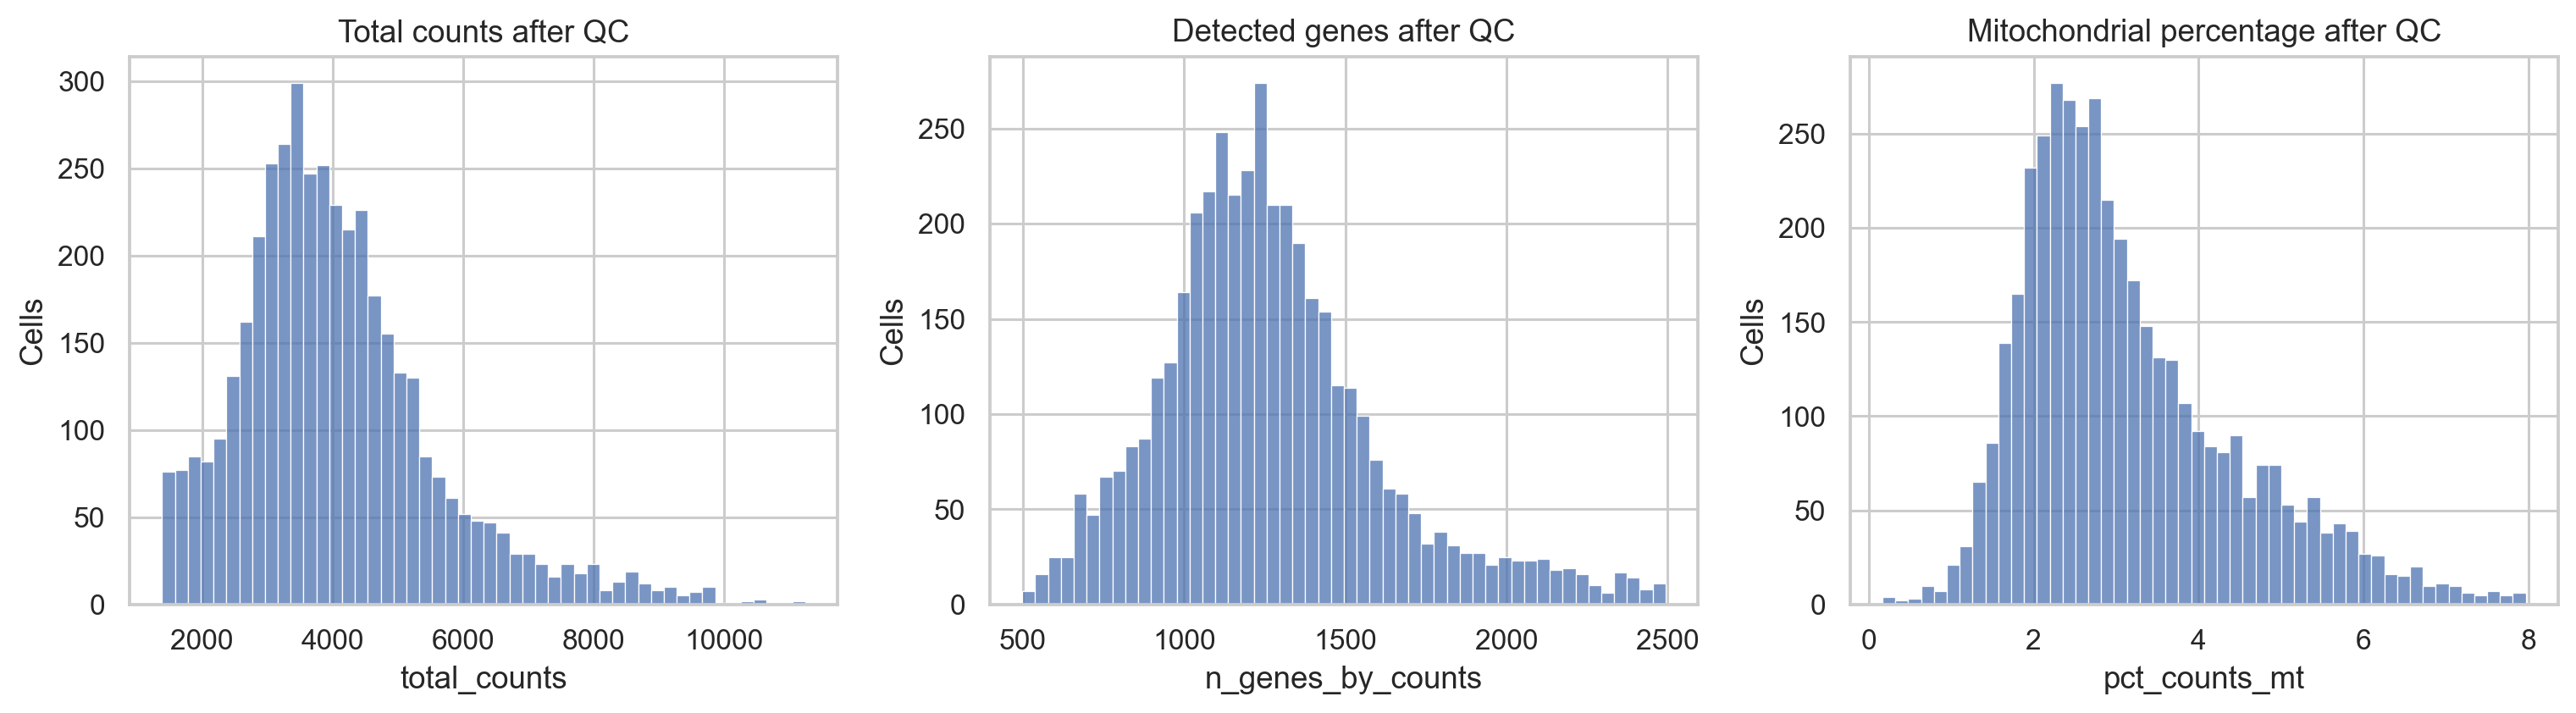

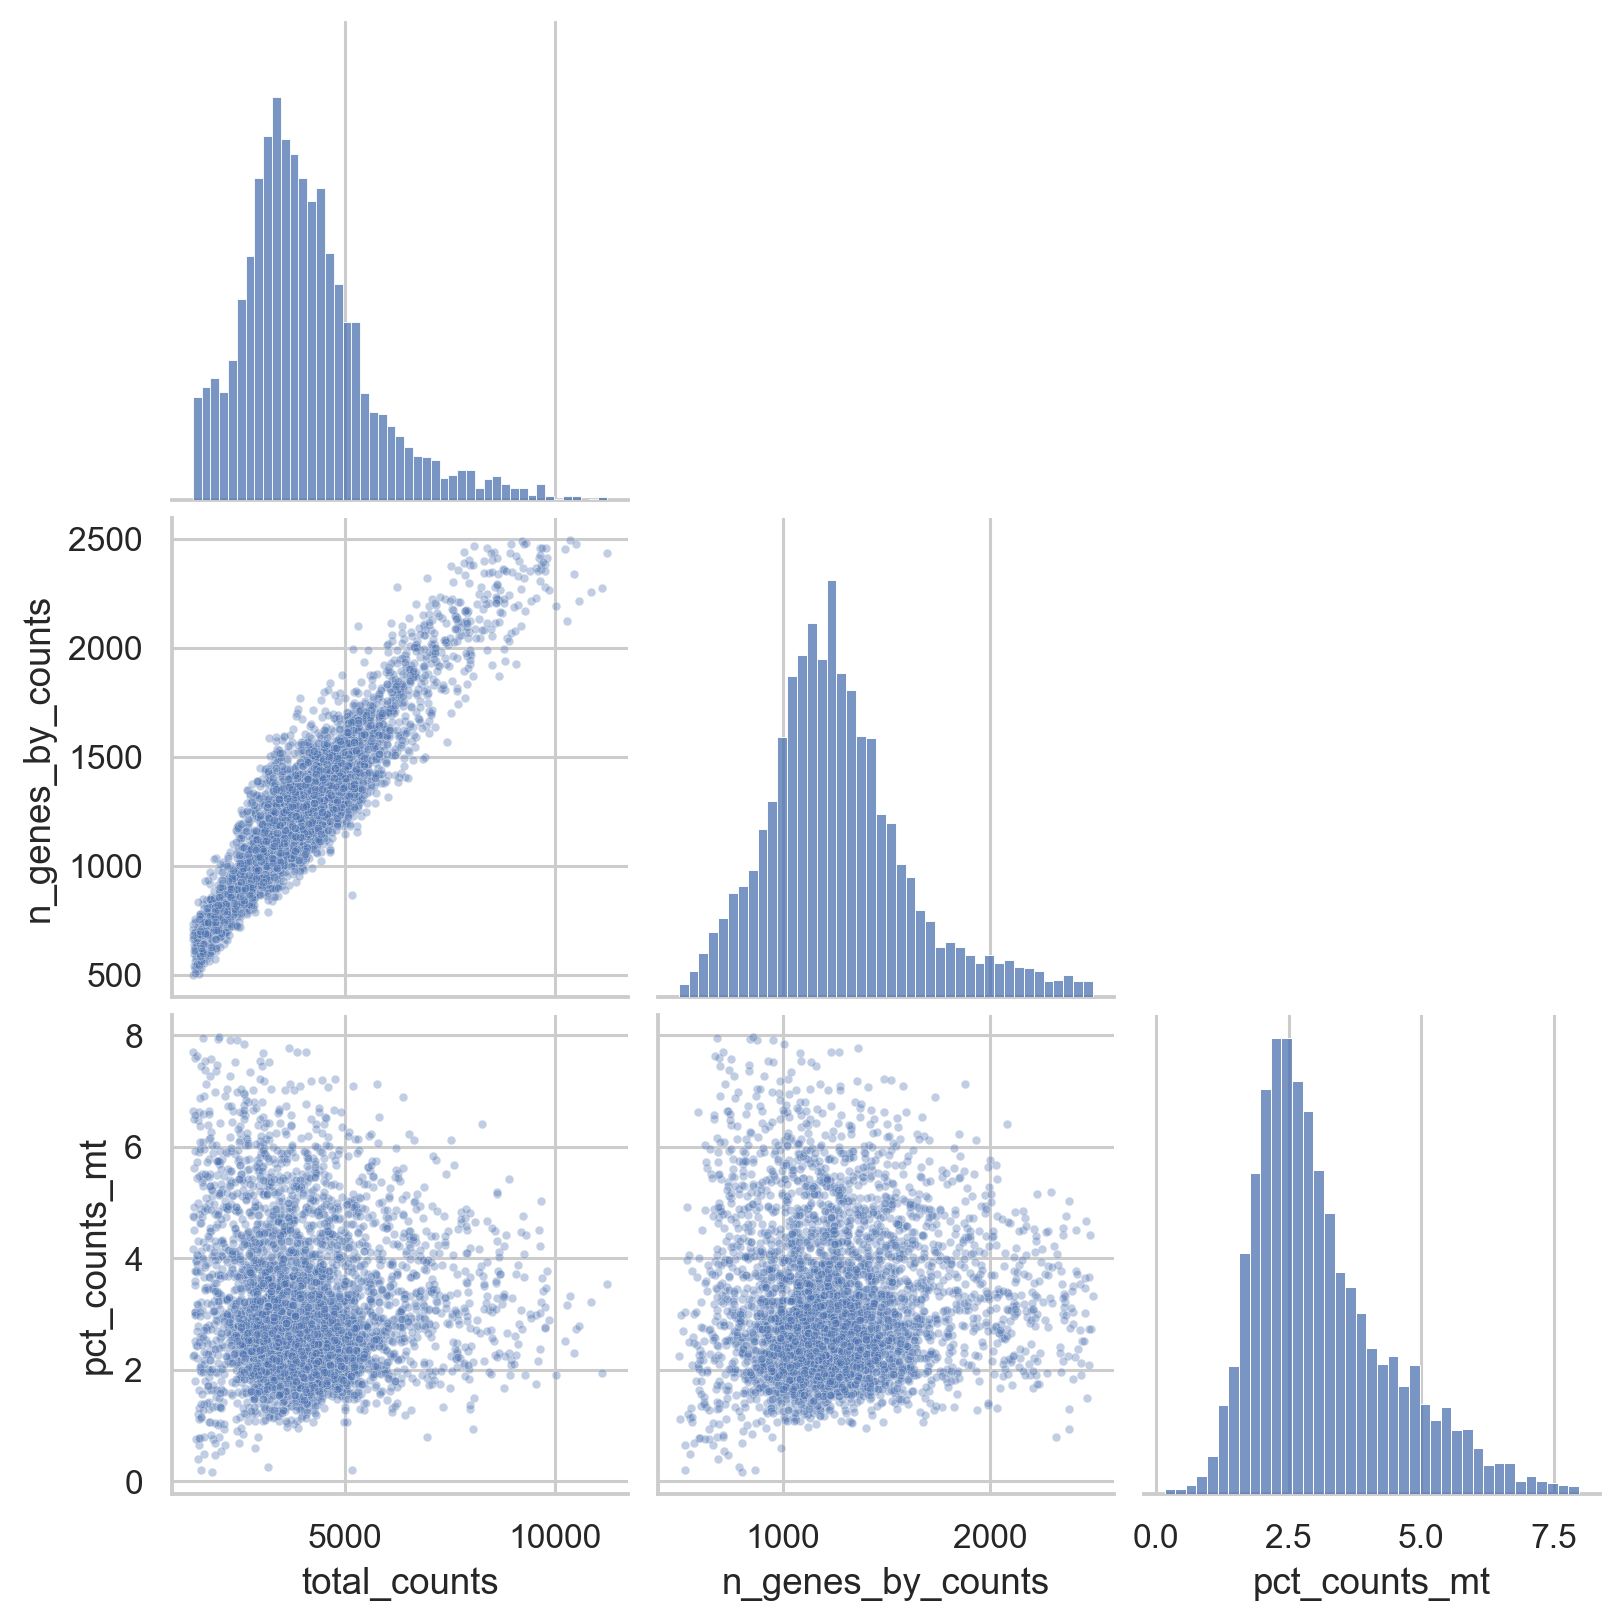

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column, title in zip(
    axes,
    qc_columns,
    ["Total counts after QC", "Detected genes after QC", "Mitochondrial percentage after QC"],
):
    sns.histplot(adata.obs[column], bins=50, ax=axis)
    axis.set(title=title, xlabel=column, ylabel="Cells")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_post_qc_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

pair_data = adata.obs[qc_columns].copy()
sns.pairplot(pair_data, corner=True, plot_kws={"s": 8, "alpha": 0.35})
plt.savefig(FIGURES / "pbmc4k_phase2_qc_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Explore overall gene expression

Highly expressed genes can reflect real immune programs, but mitochondrial, ribosomal, and housekeeping genes can also rank highly. Expression abundance alone does not determine cell identity.

,gene,mean_log_normalized_expression,fraction_of_cells_expressing
8632,MALAT1,6.219554,1.000000
6530,TMSB4X,4.980274,1.000000
1057,RPS27,4.914678,1.000000
11593,B2M,4.899967,1.000000
5376,EEF1A1,4.672602,1.000000
10107,RPL41,4.578607,0.999760
6976,RPL10,4.576945,1.000000
10606,RPL21,4.543260,0.999520
3990,RPL34,4.535150,0.999520
12753,RPL13,4.510355,1.000000


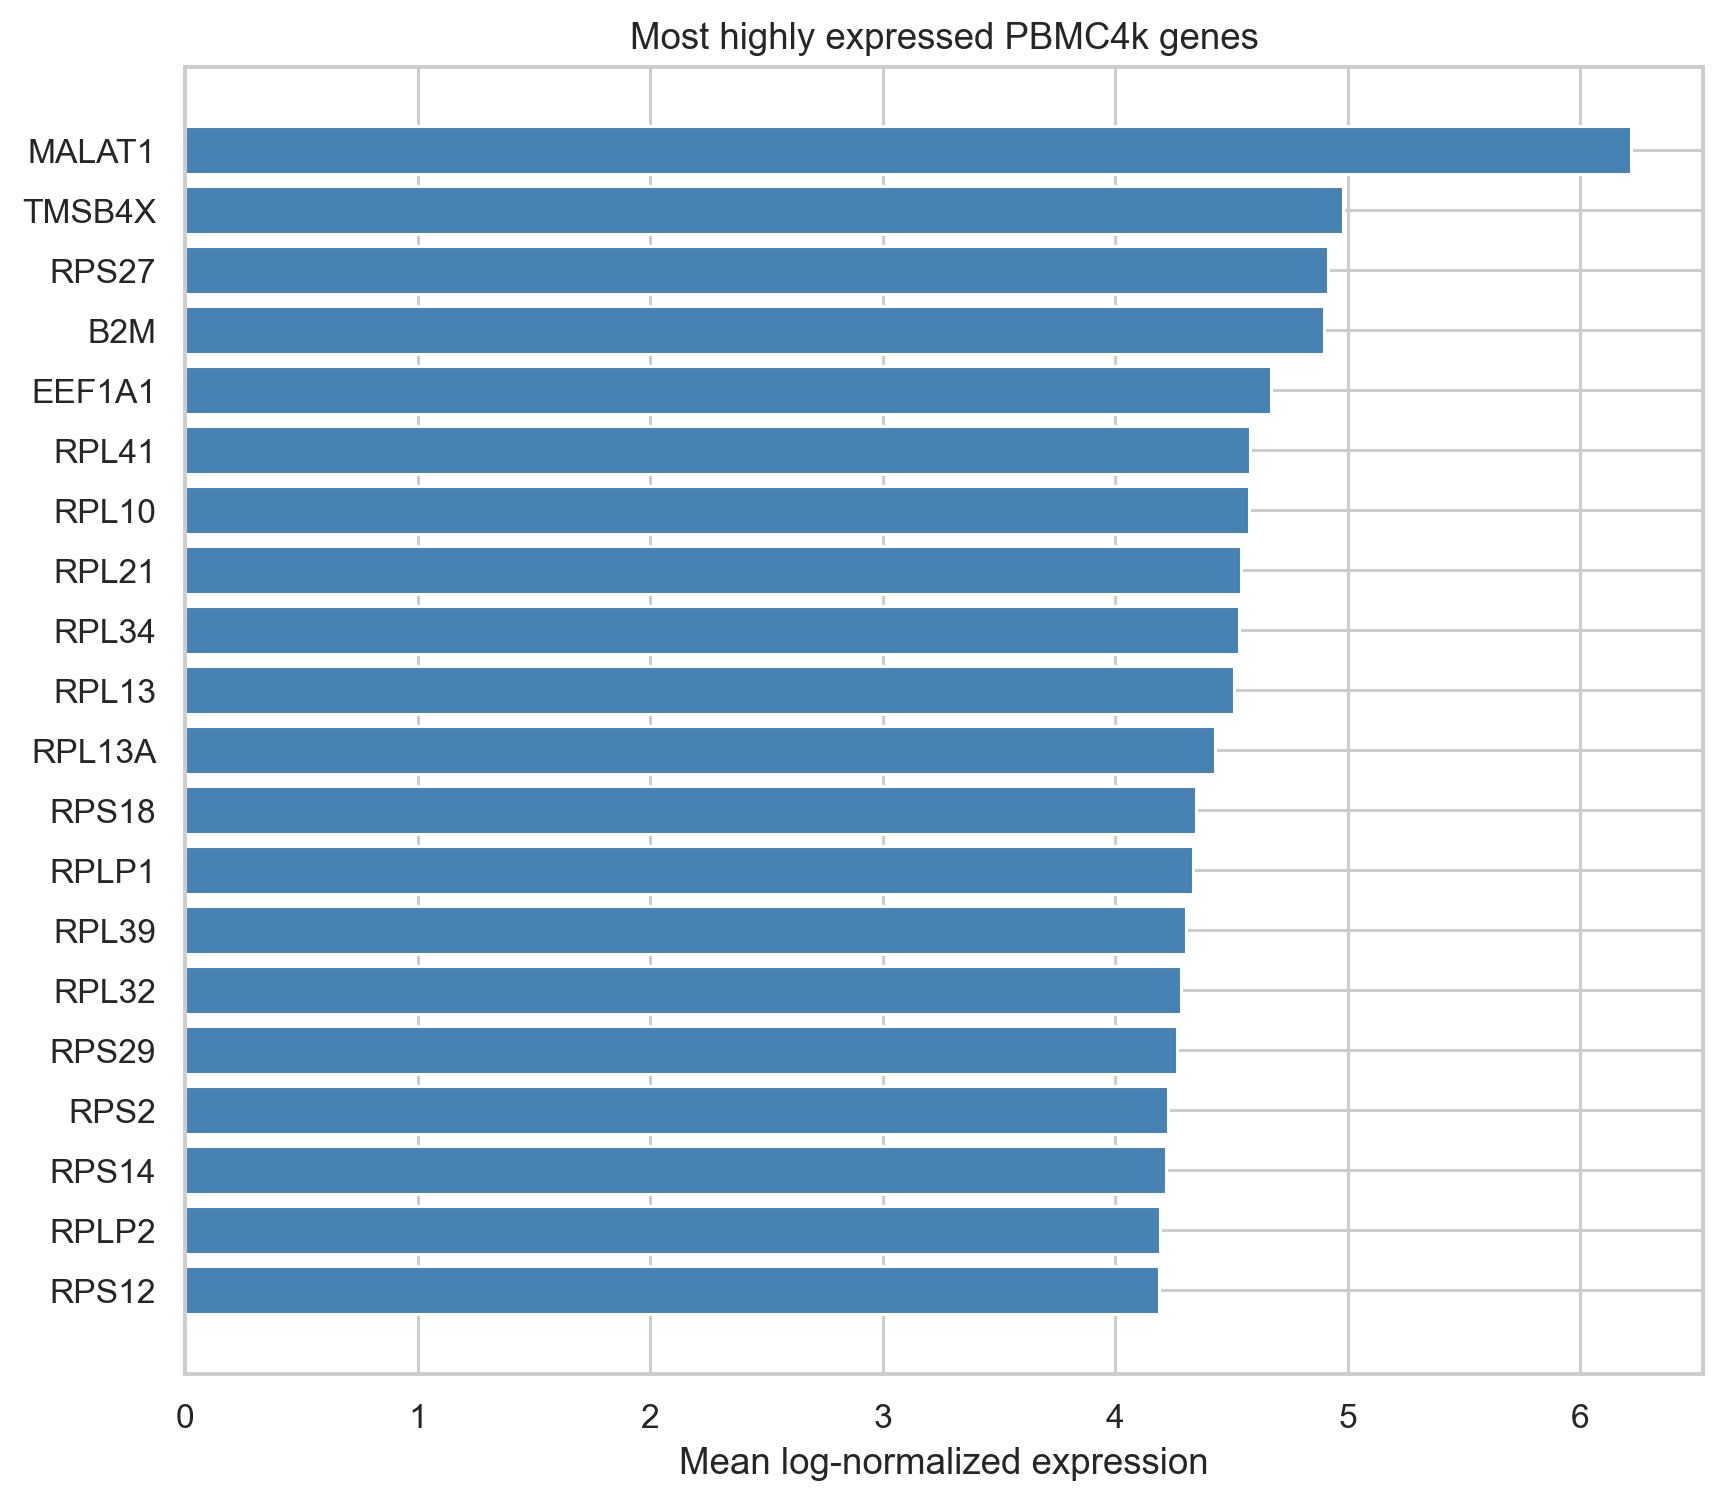

In [5]:
raw_X = adata.raw.X
mean_expression = np.asarray(raw_X.mean(axis=0)).ravel()
if sparse.issparse(raw_X):
    fraction_expressing = np.asarray(raw_X.getnnz(axis=0)).ravel() / adata.n_obs
else:
    fraction_expressing = np.mean(np.asarray(raw_X) > 0, axis=0)

gene_summary = pd.DataFrame(
    {
        "gene": adata.raw.var_names,
        "mean_log_normalized_expression": mean_expression,
        "fraction_of_cells_expressing": fraction_expressing,
    }
).sort_values("mean_log_normalized_expression", ascending=False)
display(gene_summary.head(25))
gene_summary.to_csv(TABLES / "pbmc4k_phase2_gene_expression_summary.csv", index=False)

top = gene_summary.head(20).sort_values("mean_log_normalized_expression")
plt.figure(figsize=(8, 7))
plt.barh(top["gene"], top["mean_log_normalized_expression"], color="steelblue")
plt.xlabel("Mean log-normalized expression")
plt.title("Most highly expressed PBMC4k genes")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_highly_expressed_genes.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. PBMC3k marker panel reused unchanged

For consistency, the following dictionary is copied exactly from `PBMC3k/notebooks/04_marker_gene_discovery.ipynb`. These are reference programs for later interpretation, not training labels.

In [6]:
pbmc_marker_panel = {
    "Naive/helper T": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB", "CCR7", "MAL"],
    "Cytotoxic T": ["CD3D", "CD3E", "CD8A", "CD8B", "CCL5", "NKG7"],
    "NK": ["NKG7", "GNLY", "KLRD1", "PRF1", "GZMB"],
    "B": ["MS4A1", "CD79A", "CD37", "CD74", "HLA-DRA", "CD79B"],
    "CD14 monocyte": ["LYZ", "LST1", "CTSS", "FCER1G", "S100A8", "S100A9", "CTSD"],
    "FCGR3A monocyte": ["LYZ", "LST1", "FCGR3A", "MS4A7", "LILRB1", "IFITM3"],
    "Dendritic": ["FCER1A", "CST3", "CD1C", "CLEC10A"],
    "Platelet": ["PPBP", "PF4", "NRGN", "GNG11"],
}

raw_genes = set(adata.raw.var_names)
missing_reference_genes = {
    cell_type: [gene for gene in genes if gene not in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: [gene for gene in genes if gene in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: genes for cell_type, genes in available_pbmc_markers.items() if genes
}
display(pd.Series(missing_reference_genes, name="markers absent from PBMC4k").to_frame())

,markers absent from PBMC4k
Naive/helper T,[]
Cytotoxic T,[]
NK,[]
B,[]
CD14 monocyte,[]
FCGR3A monocyte,[]
Dendritic,[]
Platelet,[]


## 5. Prepare the Phase 1 features for PCA

PCA and clustering use only the 2,000 genes flagged by expression standard deviation in Phase 1. The full normalized gene matrix remains available in `.raw` for marker plots and differential-expression testing.

In [7]:
feature_mask = adata.var["selected_by_pbmc4k_std"].astype(bool).to_numpy()
if feature_mask.sum() == 0:
    raise ValueError("No Phase 1 clustering features were selected.")

adata = adata[:, feature_mask].copy()
adata.layers["log_normalized"] = adata.X.copy()
print(f"Clustering matrix: {adata.n_obs:,} cells × {adata.n_vars:,} selected genes")
print(f"Full genes retained in adata.raw: {adata.raw.n_vars:,}")

Clustering matrix: 4,169 cells × 2,000 selected genes
Full genes retained in adata.raw: 16,361


## 6. PCA and technical-variation review

PCA compresses the selected gene measurements into major axes of variation. The scree plot shows how much variation each component explains. QC coloring checks whether the leading structure is dominated by library size or mitochondrial percentage.

computing PCA


    with n_comps=50


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:02)


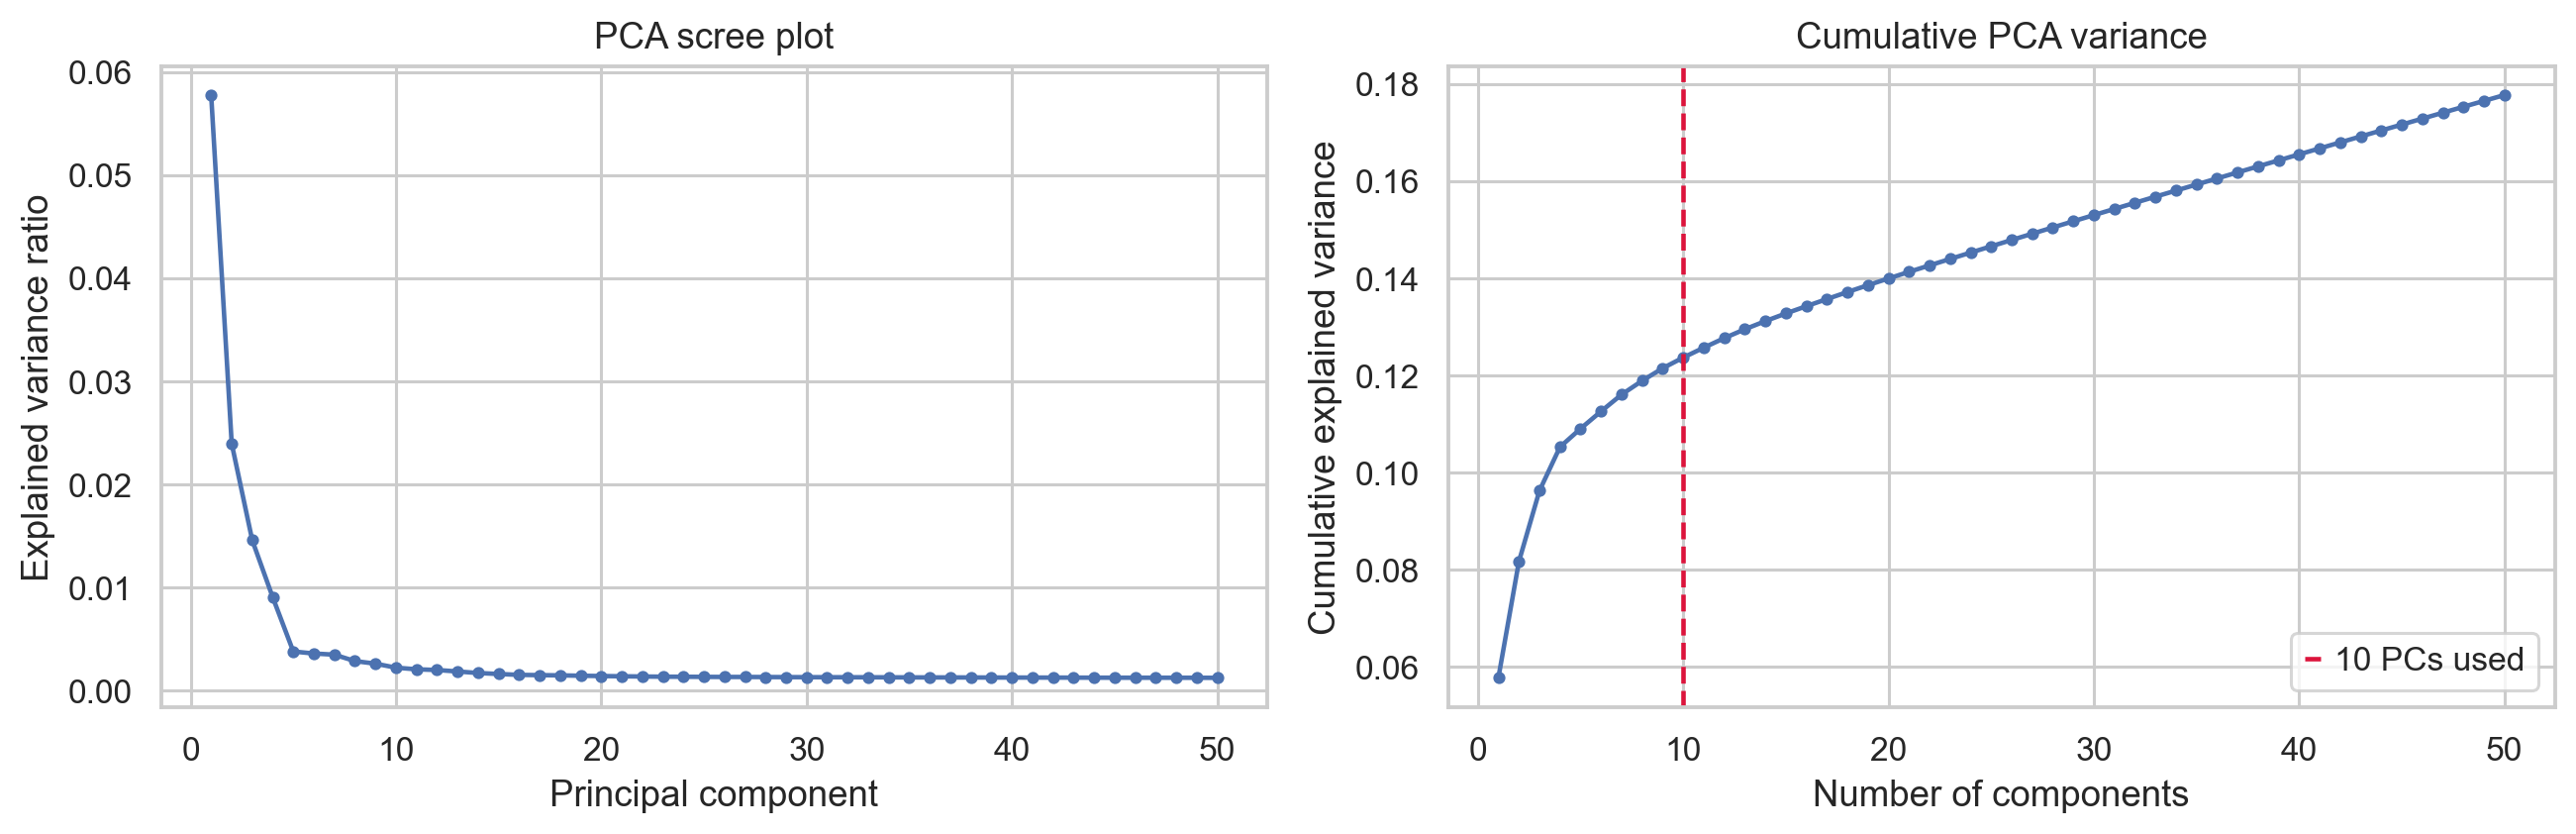

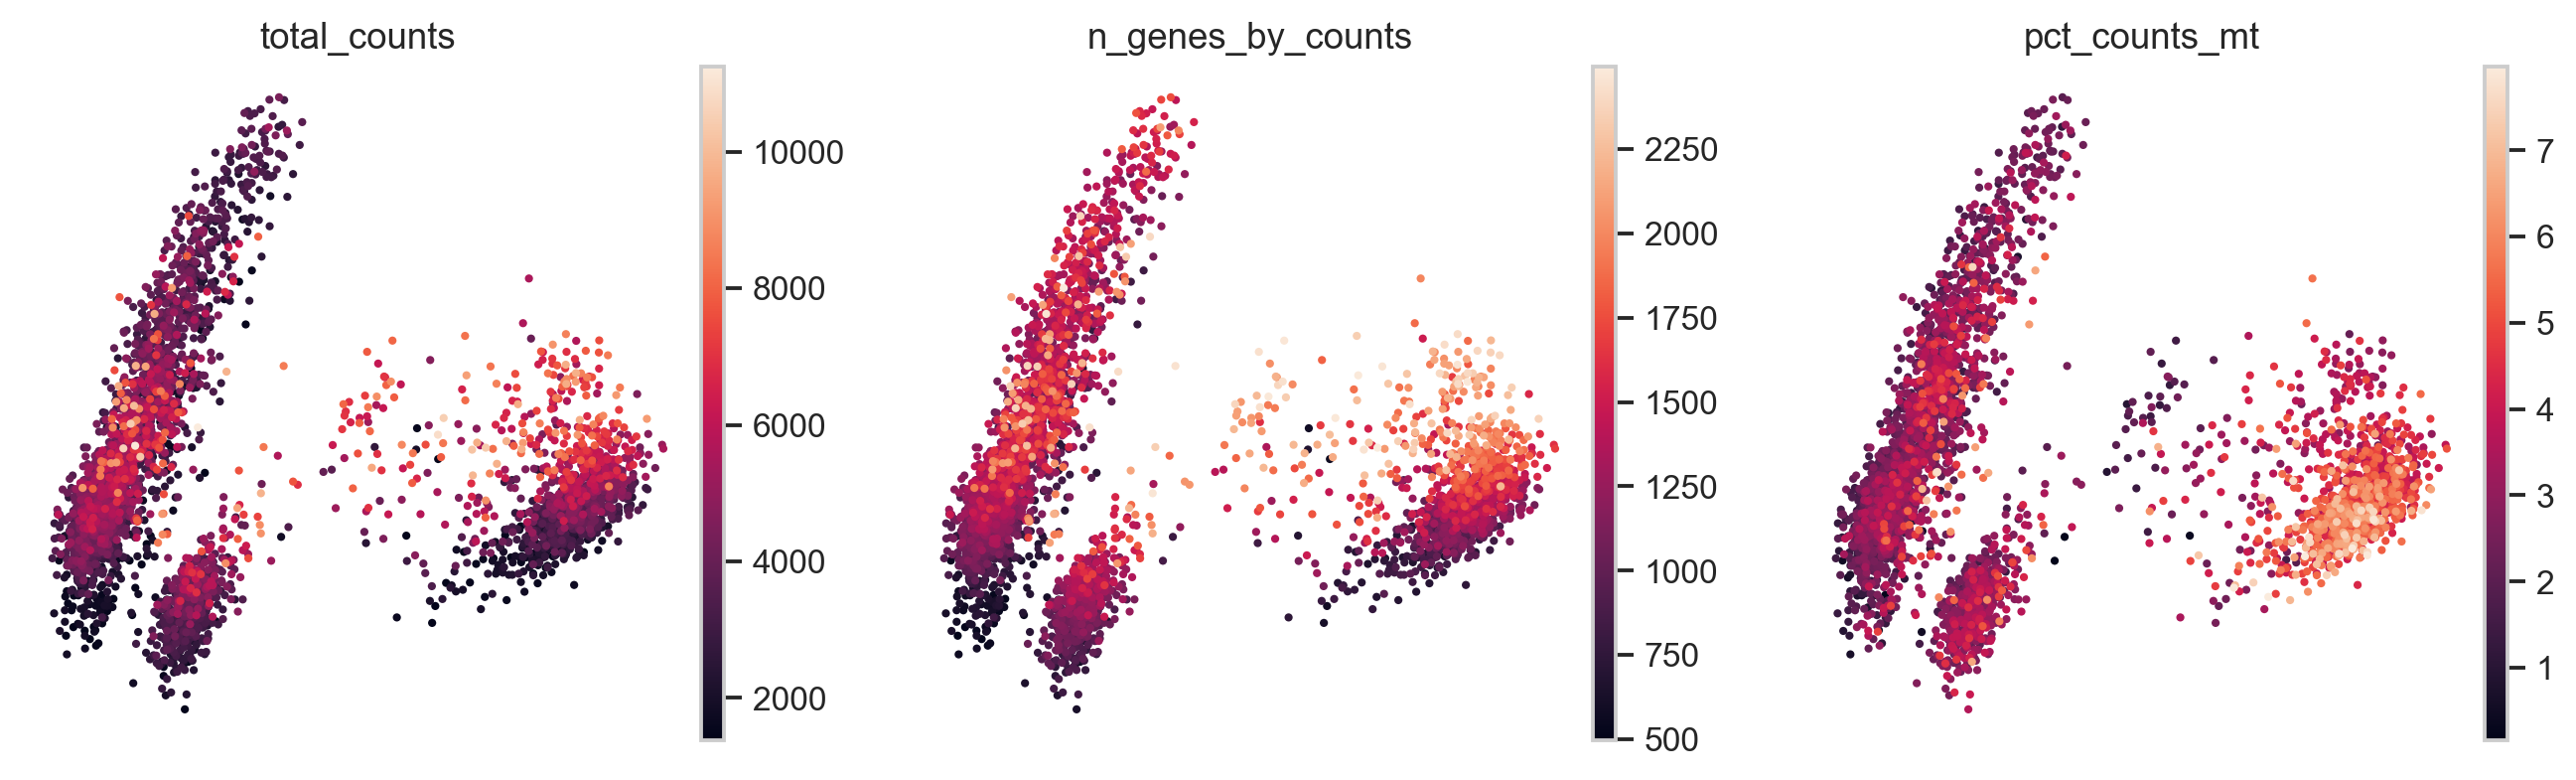

In [8]:
sc.pp.scale(adata, max_value=10)
n_pcs_available = min(50, adata.n_obs - 1, adata.n_vars - 1)
sc.tl.pca(adata, n_comps=n_pcs_available, svd_solver="arpack", random_state=RANDOM_STATE)

variance = adata.uns["pca"]["variance_ratio"]
cumulative_variance = np.cumsum(variance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(variance) + 1), variance, marker="o", markersize=3)
axes[0].set(xlabel="Principal component", ylabel="Explained variance ratio", title="PCA scree plot")
axes[1].plot(np.arange(1, len(variance) + 1), cumulative_variance, marker="o", markersize=3)
axes[1].axvline(N_PCS, color="crimson", linestyle="--", label=f"{N_PCS} PCs used")
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance", title="Cumulative PCA variance")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_pca_variance.png", dpi=160, bbox_inches="tight")
plt.show()

sc.pl.pca(adata, color=qc_columns, ncols=3, show=False)
plt.savefig(FIGURES / "pbmc4k_phase2_pca_qc.png", dpi=160, bbox_inches="tight")
plt.show()

In [9]:
loading_rows = []
for pc_index in range(min(N_PCS, adata.varm["PCs"].shape[1])):
    loadings = adata.varm["PCs"][:, pc_index]
    strongest = np.argsort(np.abs(loadings))[::-1][:10]
    for gene_index in strongest:
        loading_rows.append(
            {"PC": pc_index + 1, "gene": adata.var_names[gene_index], "loading": loadings[gene_index]}
        )
pca_loadings = pd.DataFrame(loading_rows)
display(pca_loadings)
pca_loadings.to_csv(TABLES / "pbmc4k_phase2_top_pca_loadings.csv", index=False)

qc_pc_correlations = pd.DataFrame(
    {
        metric: [
            np.corrcoef(adata.obsm["X_pca"][:, pc], adata.obs[metric].to_numpy())[0, 1]
            for pc in range(N_PCS)
        ]
        for metric in qc_columns
    },
    index=[f"PC{pc + 1}" for pc in range(N_PCS)],
)
display(qc_pc_correlations.style.format("{:.2f}").background_gradient(cmap="coolwarm", vmin=-1, vmax=1))

,PC,gene,loading
0,1,LYZ,0.082008
1,1,CSTA,0.081854
2,1,TYROBP,0.081415
3,1,MNDA,0.081307
4,1,FTL,0.081082
...,...,...,...
95,10,GNLY,-0.105402
96,10,TRGC2,0.103614
97,10,IL7R,-0.102810
98,10,ITGB1,-0.101050


,total_counts,n_genes_by_counts,pct_counts_mt
PC1,0.14,0.28,0.70
PC2,0.20,0.45,-0.07
PC3,0.01,0.14,-0.05
PC4,-0.79,-0.73,0.24
PC5,-0.02,-0.01,0.18
PC6,-0.09,-0.02,0.02
PC7,-0.11,-0.11,0.04
PC8,0.15,0.07,0.19
PC9,0.06,0.09,0.25
PC10,-0.06,-0.05,-0.04


## 7. Nearest-neighbor graph and UMAP

The graph connects locally similar cells using the PBMC3k defaults of 10 PCs and 15 neighbors. UMAP visualizes this graph in two dimensions; UMAP itself does not assign clusters.

computing neighbors


    using 'X_pca' with n_pcs = 10


/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:16)


computing UMAP


    finished (0:00:06)


,PBMC4k neighbor graph
cells,4169.000000
PCs used,10.000000
neighbors requested,15.000000
mean nonzero graph connections,19.949628


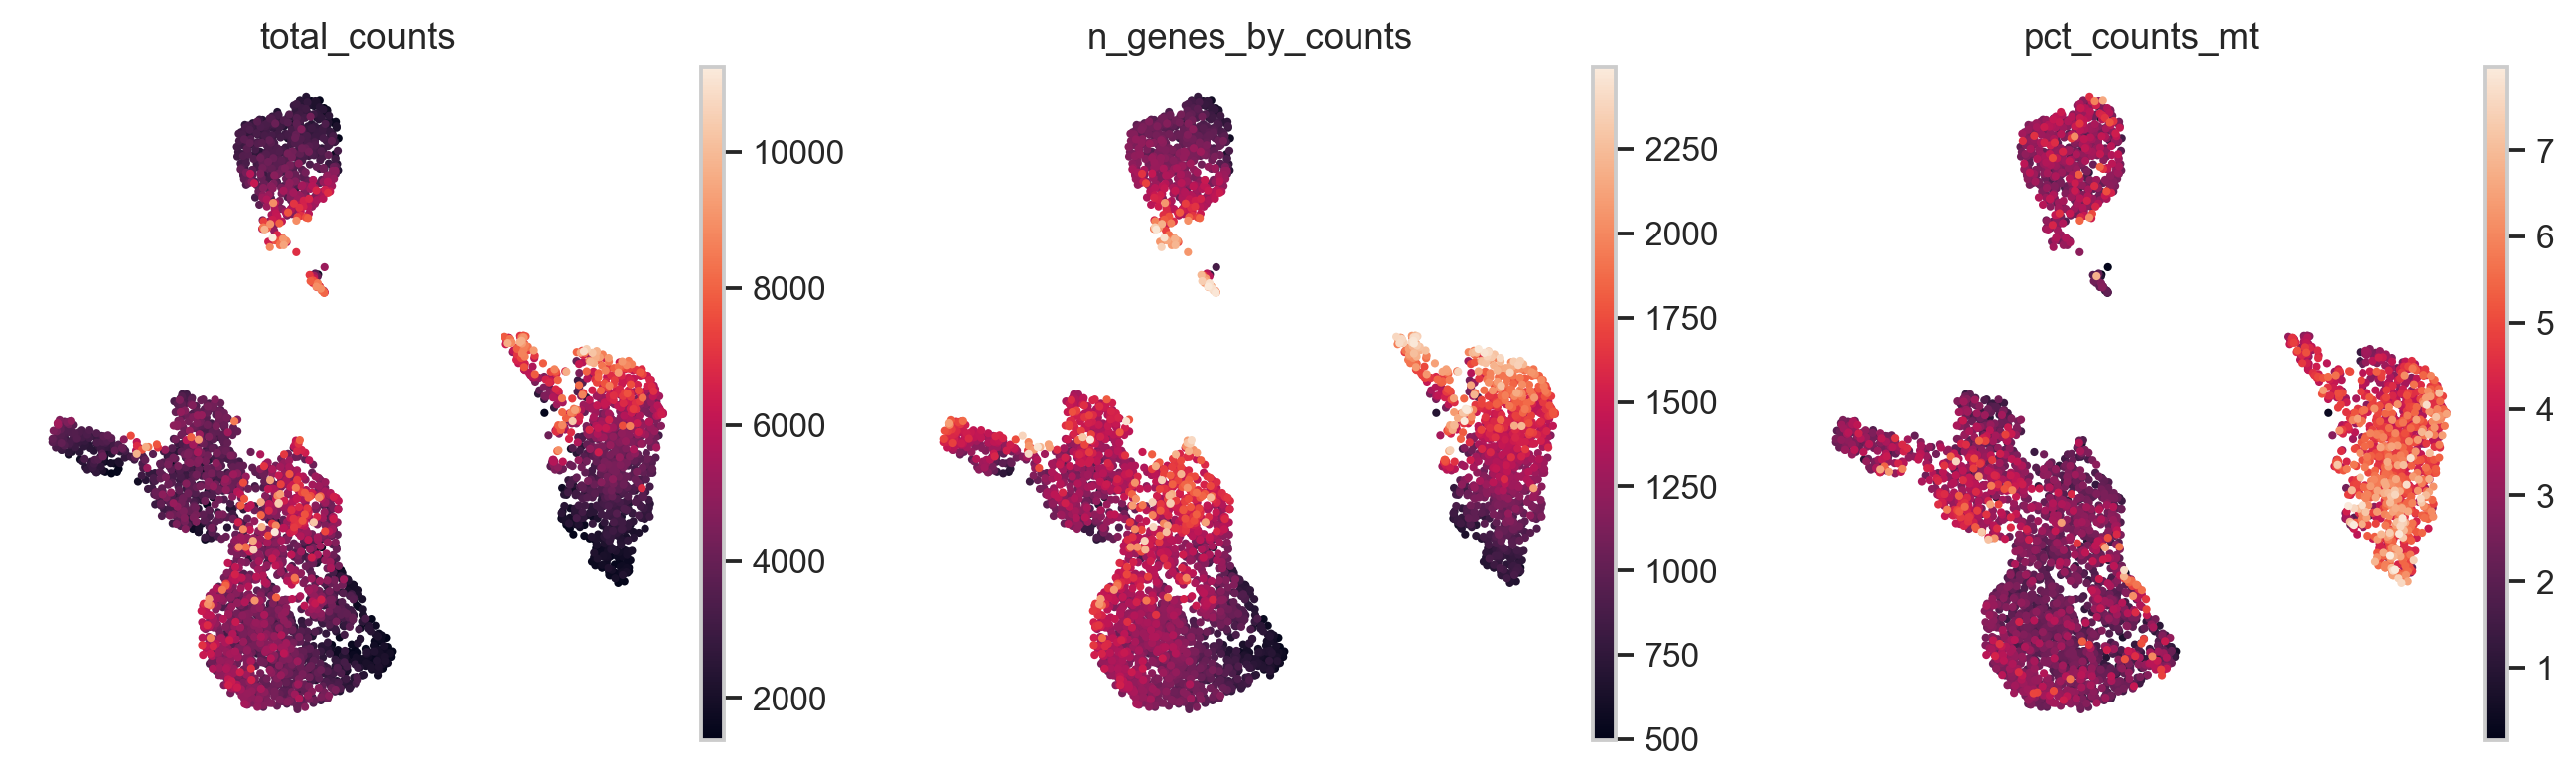

In [10]:
pcs_used = min(N_PCS, adata.obsm["X_pca"].shape[1])
sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=pcs_used,
    method="umap",
    random_state=RANDOM_STATE,
)
sc.tl.umap(adata, random_state=RANDOM_STATE)

graph_summary = pd.Series(
    {
        "cells": adata.n_obs,
        "PCs used": pcs_used,
        "neighbors requested": N_NEIGHBORS,
        "mean nonzero graph connections": float(adata.obsp["connectivities"].getnnz(axis=1).mean()),
    },
    name="PBMC4k neighbor graph",
)
display(graph_summary.to_frame())

sc.pl.umap(adata, color=qc_columns, ncols=3, show=False)
plt.savefig(FIGURES / "pbmc4k_phase2_umap_qc.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Leiden clustering

Leiden finds communities in the neighbor graph. Resolution 0.5 is reused from PBMC3k for consistency, but PBMC4k is **not forced to produce nine clusters**. The observed number and marker evidence must be reviewed on their own.

running Leiden clustering


    finished (0:00:00)


,cells,percent
leiden,,
0,864,20.7%
1,509,12.2%
2,162,3.9%
3,1050,25.2%
4,569,13.6%
5,34,0.8%
6,605,14.5%
7,44,1.1%
8,190,4.6%


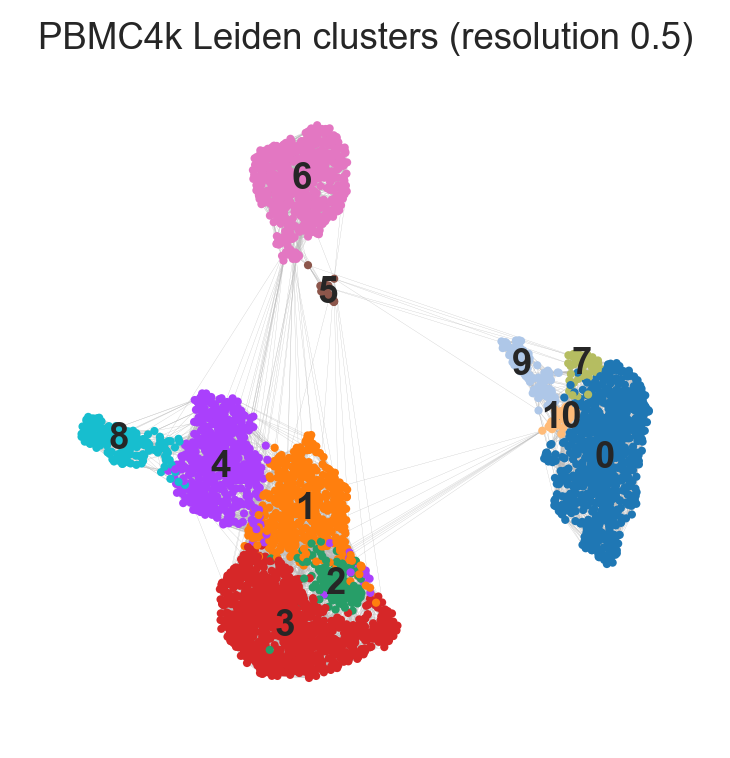

In [11]:
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RESOLUTION,
    key_added="leiden",
    random_state=RANDOM_STATE,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

cluster_sizes = adata.obs["leiden"].value_counts().sort_index().rename("cells").to_frame()
cluster_sizes["percent"] = 100 * cluster_sizes["cells"] / adata.n_obs
display(cluster_sizes.style.format({"percent": "{:.1f}%"}))
cluster_sizes.to_csv(TABLES / "pbmc4k_phase2_leiden_cluster_sizes.csv")

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    edges=True,
    edges_width=0.08,
    edges_color="#B8B8B8",
    title=f"PBMC4k Leiden clusters (resolution {LEIDEN_RESOLUTION})",
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2_leiden_umap.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Review clusters with the shared PBMC marker panel

Dot size represents the fraction of cells expressing a marker, and color represents its average expression. Interpret a cluster from several concordant markers rather than a single gene.

    using 'X_pca' with n_pcs = 50


Storing dendrogram info using `.uns['dendrogram_leiden']`


categories: 0, 1, 2, etc.
var_group_labels: Naive/helper T, Cytotoxic T, NK, etc.


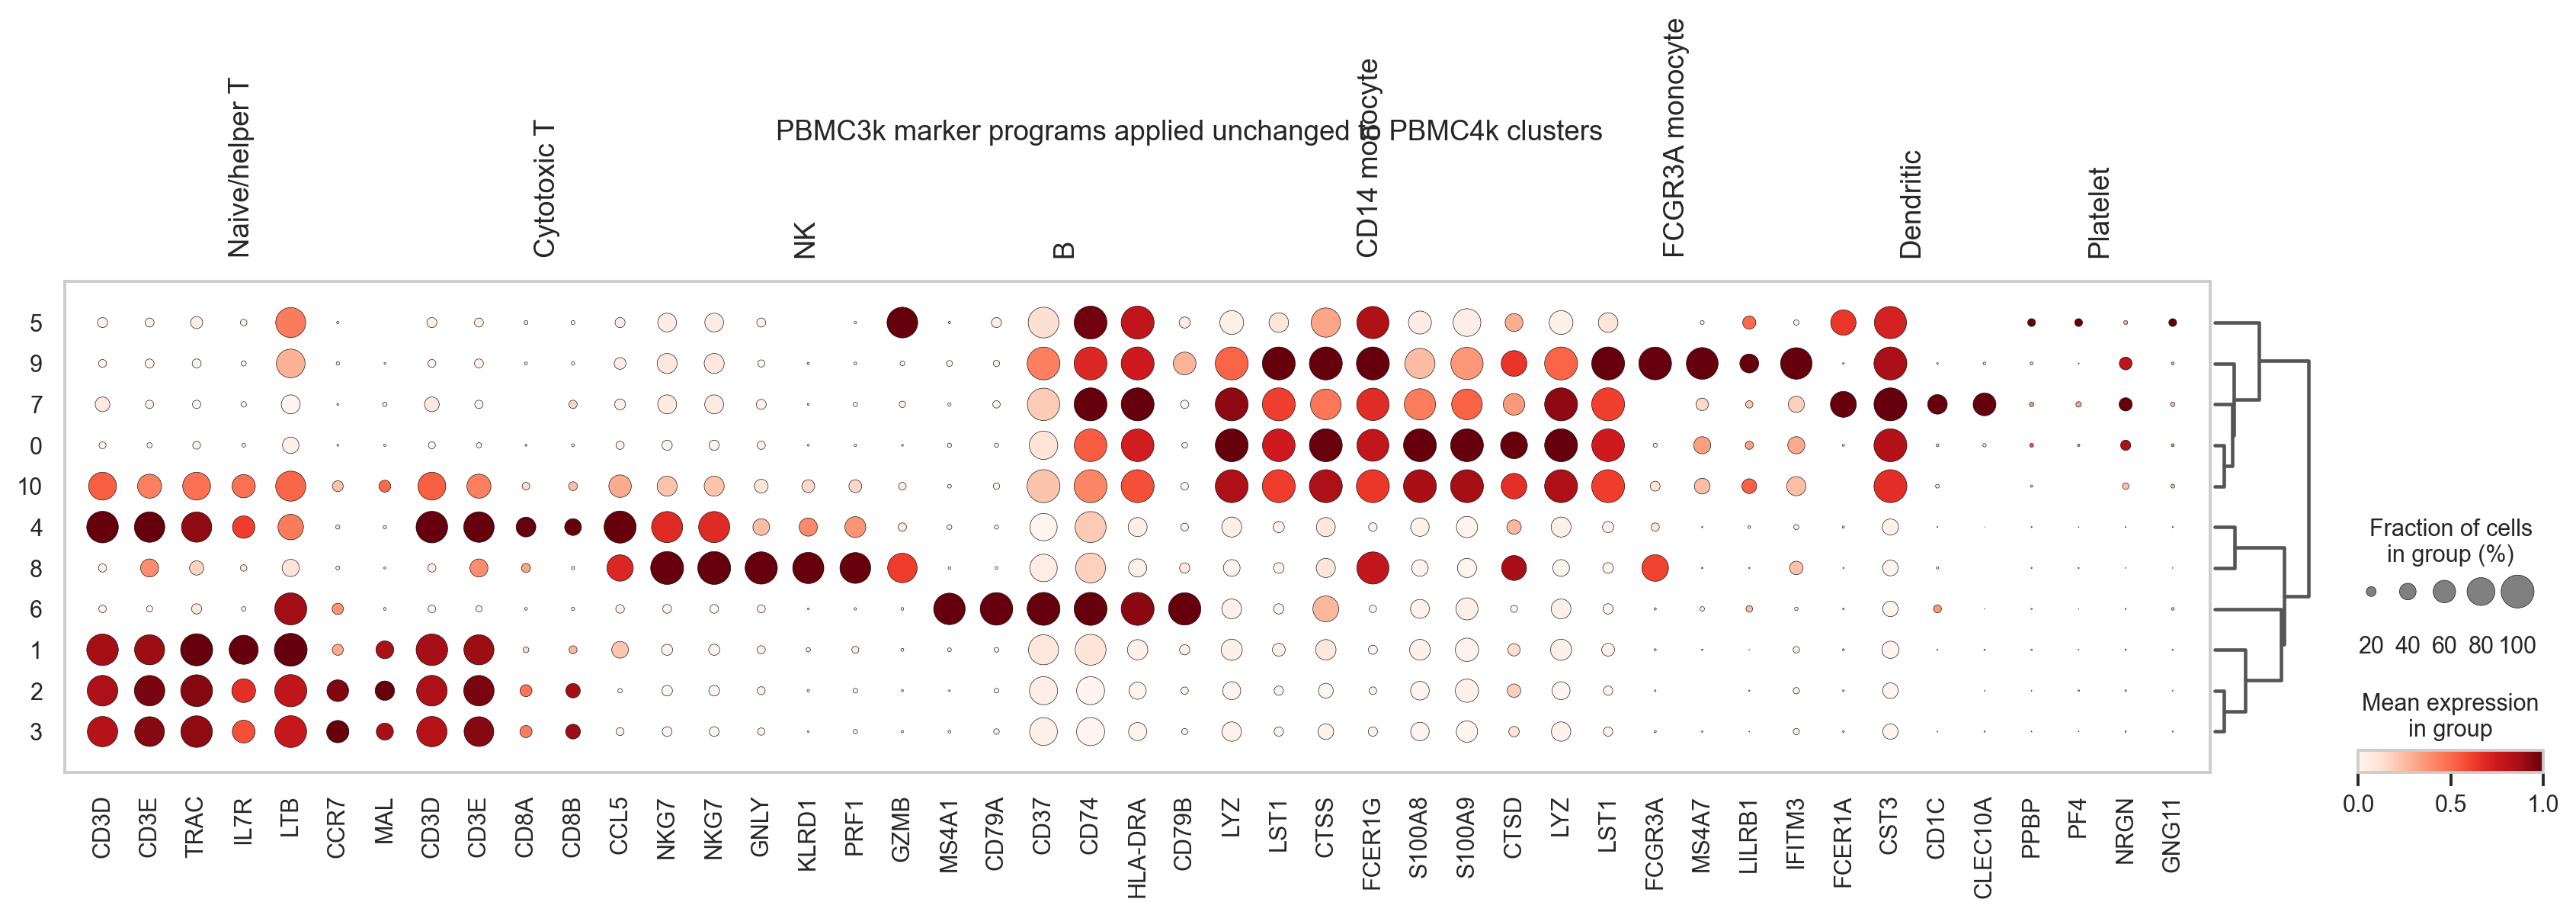

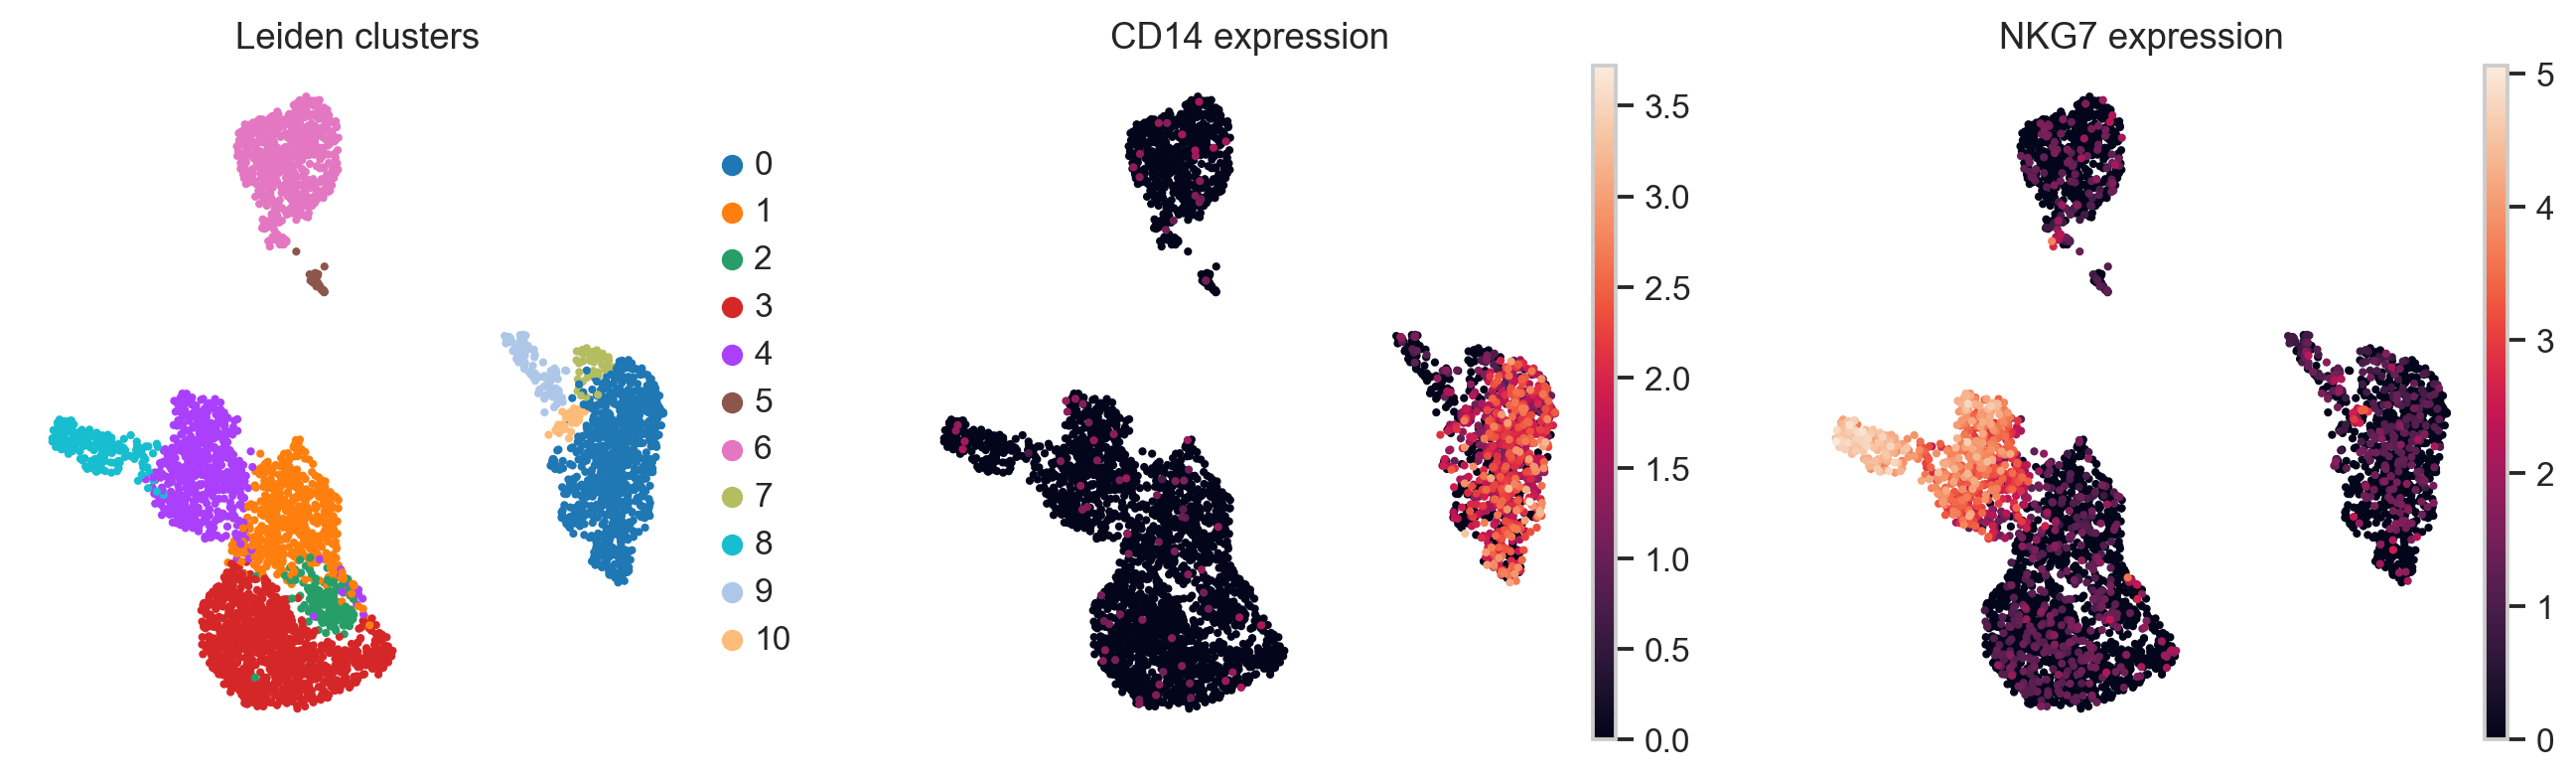

In [12]:
sc.pl.dotplot(
    adata,
    available_pbmc_markers,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    dendrogram=True,
    title="PBMC3k marker programs applied unchanged to PBMC4k clusters",
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2_known_marker_dotplot.png", dpi=160, bbox_inches="tight")
plt.show()

tutorial_markers = [gene for gene in ["CD14", "NKG7"] if gene in raw_genes]
sc.pl.umap(
    adata,
    color=["leiden", *tutorial_markers],
    ncols=3,
    use_raw=True,
    title=["Leiden clusters", *[f"{gene} expression" for gene in tutorial_markers]],
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2_cd14_nkg7_umap.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Discover data-derived cluster markers

Wilcoxon tests compare each Leiden cluster with all other cells using every normalized gene in `.raw`. These rankings are exploratory evidence; they do not automatically prove a cell-type identity.

ranking genes


    finished (0:00:02)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,LYZ,44.805836,6.448457,0.000000e+00,0.000000e+00,0.998843,0.530106
1,0,S100A8,44.472748,6.243995,0.000000e+00,0.000000e+00,0.997685,0.501059
2,0,S100A9,44.438477,6.018807,0.000000e+00,0.000000e+00,0.994213,0.598790
3,0,FTL,43.427753,3.164687,0.000000e+00,0.000000e+00,1.000000,0.994251
4,0,CTSS,43.362595,4.403078,0.000000e+00,0.000000e+00,0.997685,0.523147
...,...,...,...,...,...,...,...,...
163615,10,MNDA,6.298705,2.731009,3.001437e-10,8.184419e-07,0.942857,0.276246
163616,10,LST1,6.252095,2.676088,4.049832e-10,8.660922e-07,1.000000,0.410982
163617,10,CTSS,6.245114,2.659846,4.234911e-10,8.660922e-07,1.000000,0.618287
163618,10,VCAN,6.208376,2.856979,5.353480e-10,9.397408e-07,0.857143,0.221335


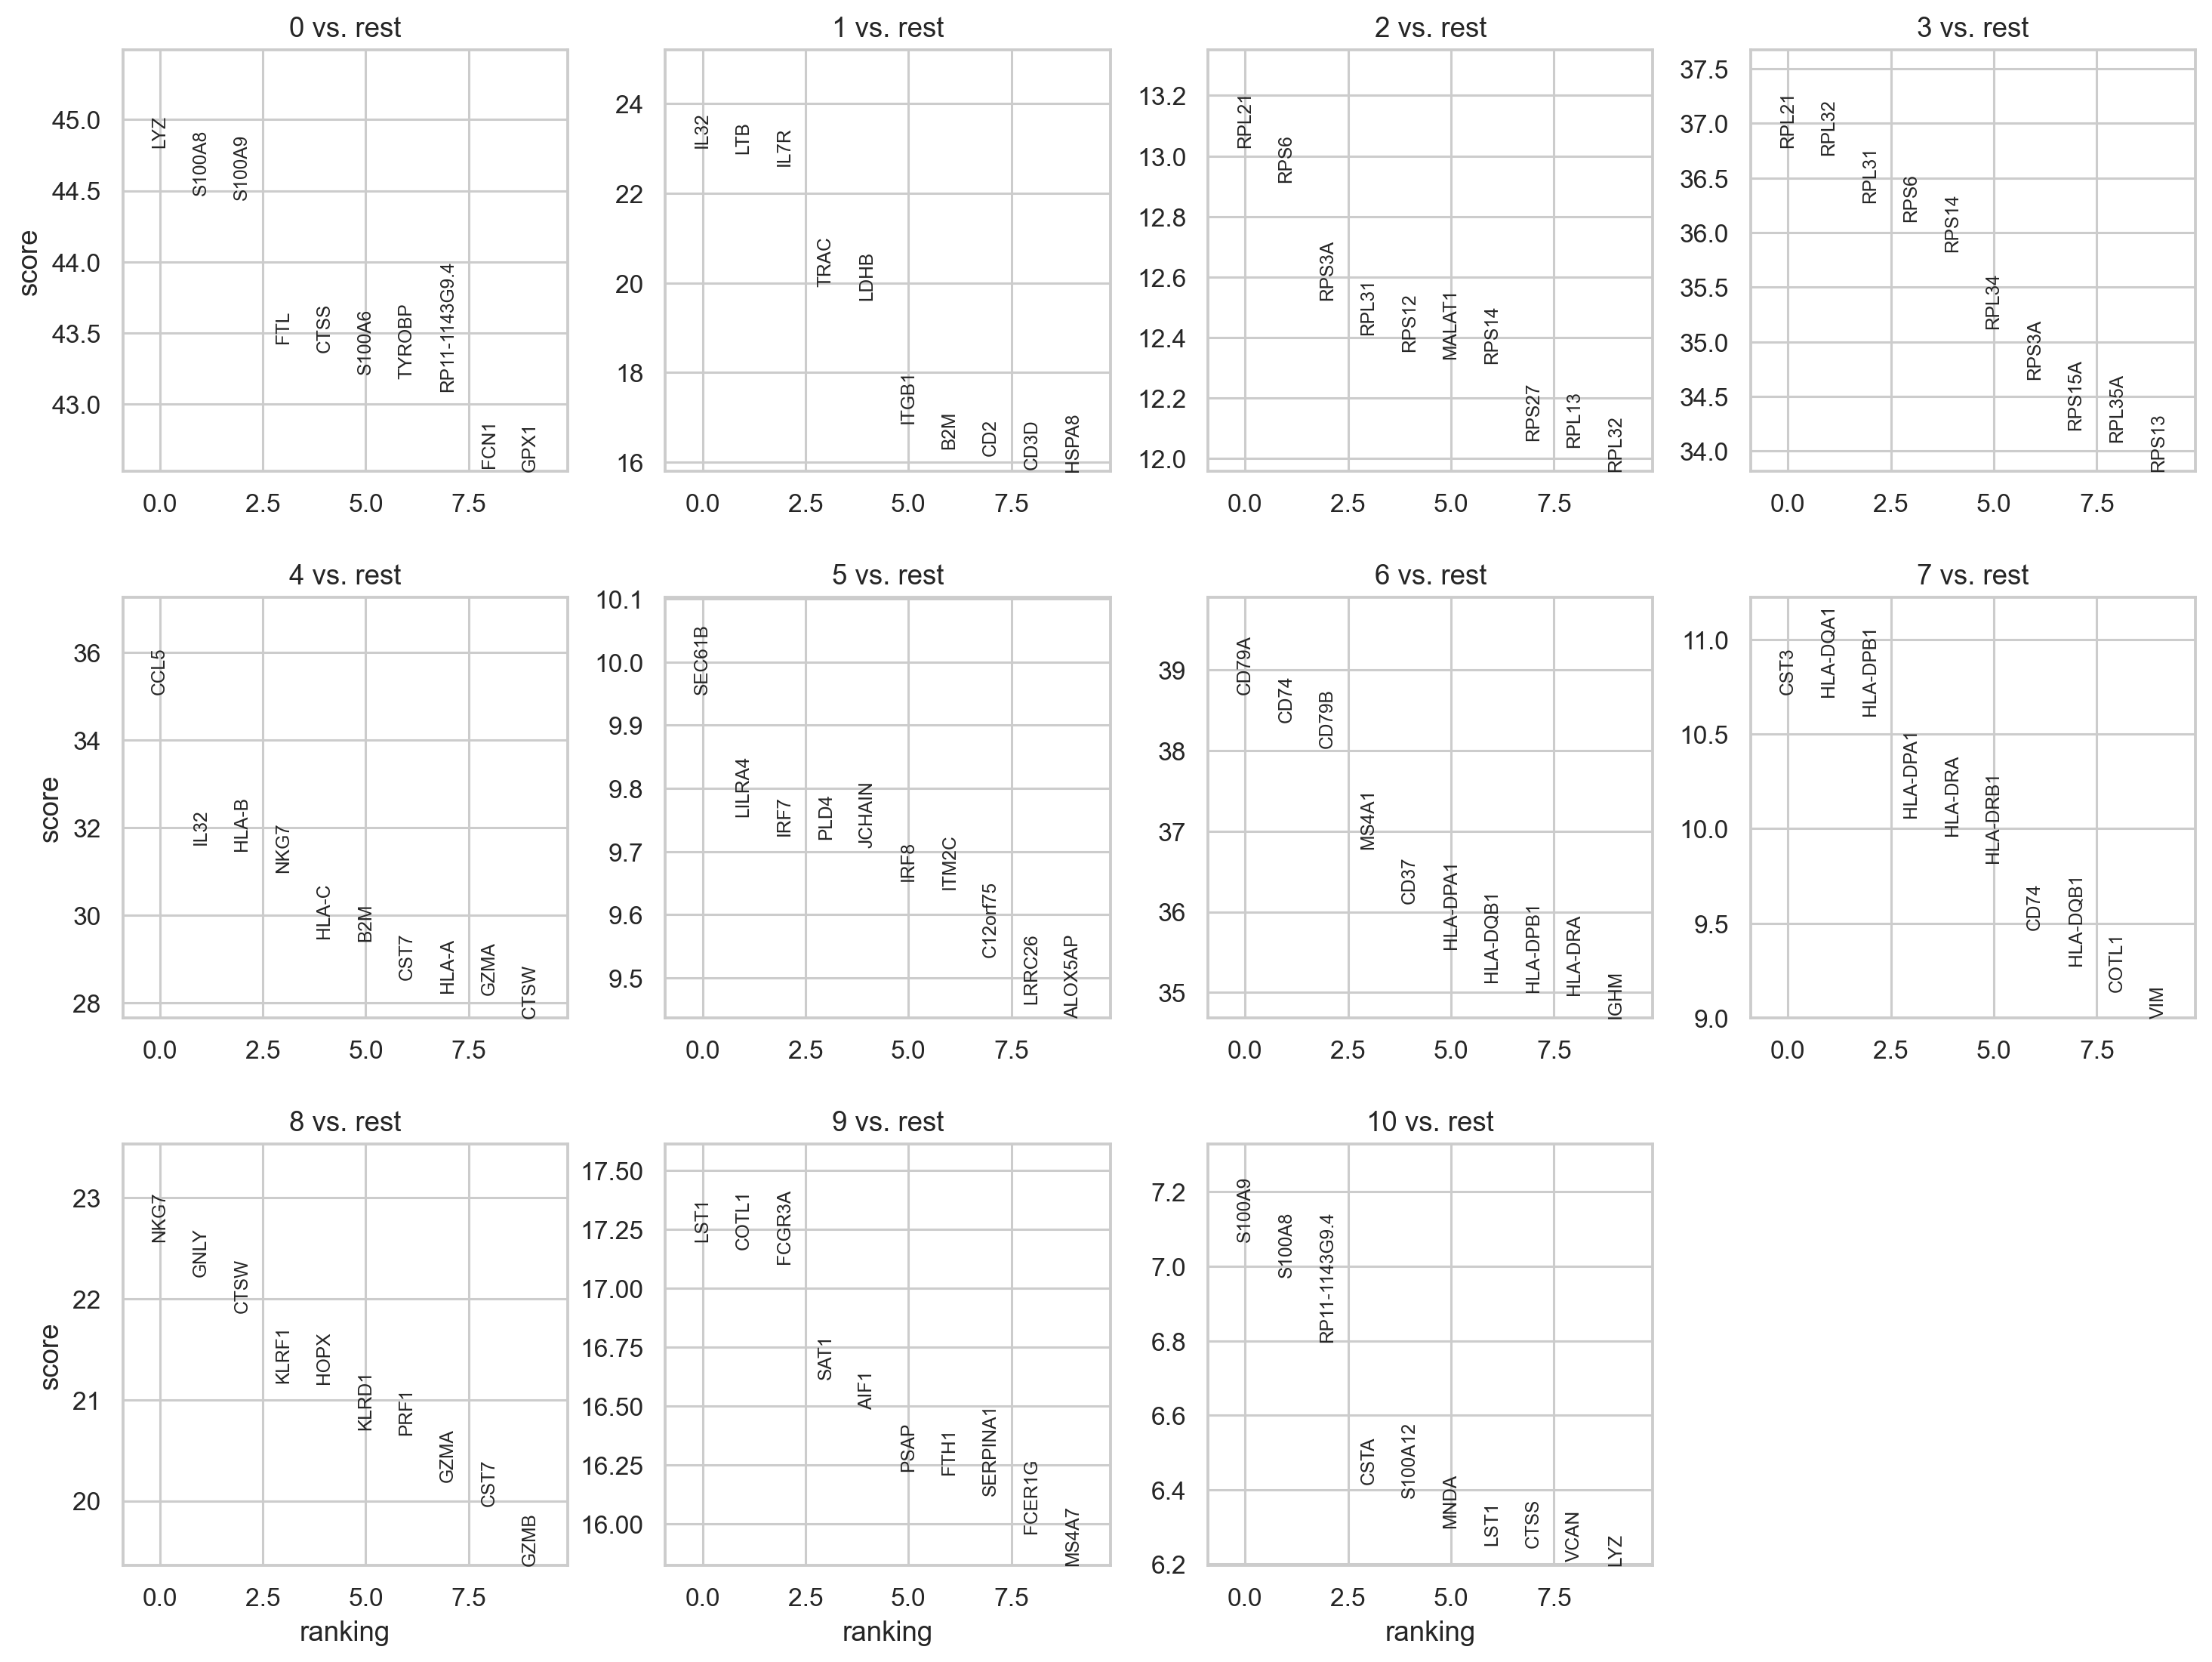

In [13]:
RANK_KEY = "rank_genes_groups_leiden"
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    reference="rest",
    use_raw=True,
    pts=True,
    corr_method="benjamini-hochberg",
    key_added=RANK_KEY,
)

all_markers = sc.get.rank_genes_groups_df(adata, group=None, key=RANK_KEY)
all_markers["group"] = all_markers["group"].astype(str)
all_markers.to_csv(TABLES / "pbmc4k_phase2_all_marker_statistics.csv", index=False)

top_markers = all_markers.groupby("group", observed=True).head(N_MARKERS_TO_DISPLAY).copy()
display(top_markers)
top_markers.to_csv(TABLES / "pbmc4k_phase2_top10_markers_per_cluster.csv", index=False)

sc.pl.rank_genes_groups(
    adata,
    key=RANK_KEY,
    n_genes=N_MARKERS_TO_DISPLAY,
    sharey=False,
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase2_ranked_cluster_markers.png", dpi=160, bbox_inches="tight")
plt.show()

## Interpretation checkpoint

Before assigning any biological labels, confirm that:

- each proposed identity is supported by several related markers;
- the marker program is concentrated in the relevant cluster;
- clusters are not separated mainly by mitochondrial percentage or library size;
- mitochondrial, ribosomal, stress, or cell-cycle genes are not mistaken for cell identity;
- conflicting lineage programs are reviewed as possible doublets;
- broad or ambiguous labels are used when subtype evidence is insufficient.

Final PBMC4k annotations should be reviewed separately before they are used to evaluate XGBoost.

## 11. Save the exploratory result

The saved object contains scaled Phase 1 features, PCA, the neighbor graph, UMAP, Leiden labels, marker rankings, normalized selected-gene expression in `layers['log_normalized']`, and the full normalized gene matrix in `.raw`. It intentionally contains no final cell-type labels.

In [14]:
adata.uns["phase2_eda"] = {
    "random_state": RANDOM_STATE,
    "pca_components_used": pcs_used,
    "nearest_neighbors": N_NEIGHBORS,
    "leiden_resolution": LEIDEN_RESOLUTION,
    "observed_leiden_clusters": int(adata.obs["leiden"].nunique()),
    "reference_marker_source": "PBMC3k/notebooks/04_marker_gene_discovery.ipynb; copied unchanged",
    "final_cell_types_assigned": False,
}
adata.write_h5ad(OUTPUT, compression="gzip")

final_summary = pd.Series(
    {
        "cells": adata.n_obs,
        "PCA features": adata.n_vars,
        "full normalized genes in raw": adata.raw.n_vars,
        "PCs used": pcs_used,
        "nearest neighbors": N_NEIGHBORS,
        "Leiden resolution": LEIDEN_RESOLUTION,
        "observed clusters": adata.obs["leiden"].nunique(),
        "output": str(OUTPUT),
    },
    name="PBMC4k Phase 2 result",
)
display(final_summary.to_frame())
print(f"Saved {OUTPUT.name} ({OUTPUT.stat().st_size / 1024**2:.1f} MB)")

,PBMC4k Phase 2 result
cells,4169
PCA features,2000
full normalized genes in raw,16361
PCs used,10
nearest neighbors,15
Leiden resolution,0.5
observed clusters,11
output,/Users/Ema/Desktop/cosmos/26-the-backpropagato...


Saved pbmc4k_phase2_clustered.h5ad (64.6 MB)


## 12. Validate rare clusters 5, 7, and 10

Small clusters are not automatically errors: PBMC samples can contain genuine rare dendritic populations. This section checks three kinds of evidence before any cells are removed:

1. **Scrublet doublet evidence:** cells containing RNA profiles from two captured cells should receive higher doublet scores.
2. **Leiden stability:** a credible population should remain reasonably cohesive across nearby resolutions and random seeds.
3. **Biological coherence:** several related markers should support one lineage; conflicting unrelated lineages can indicate doublets.

The checks add flags and evidence only. They do not delete cells or replace the resolution-0.5 Leiden labels.

In [15]:
# Scrublet must use original integer counts and should run before the manual
# Phase 1 cell filters. Reload all 4,340 cells from the official 10x matrix,
# score them together, and then transfer scores to the 4,169 retained cells.
RAW_MATRIX = PROJECT / "data" / "raw" / "filtered_gene_bc_matrices" / "GRCh38"
if not RAW_MATRIX.is_dir():
    raise FileNotFoundError(f"Expected extracted 10x matrix at {RAW_MATRIX}")

doublet_adata = sc.read_10x_mtx(RAW_MATRIX, var_names="gene_symbols", cache=False)
doublet_adata.var_names_make_unique()
doublet_adata.obs_names = "pbmc4k_" + doublet_adata.obs_names.astype(str)

EXPECTED_DOUBLET_RATE = 0.05
sc.pp.scrublet(
    doublet_adata,
    expected_doublet_rate=EXPECTED_DOUBLET_RATE,
    random_state=RANDOM_STATE,
)

transferred_scores = doublet_adata.obs["doublet_score"].reindex(adata.obs_names)
transferred_predictions = doublet_adata.obs["predicted_doublet"].reindex(adata.obs_names)
if transferred_scores.isna().any() or transferred_predictions.isna().any():
    raise ValueError("Could not match every retained PBMC4k cell to the pre-QC Scrublet result.")

adata.obs["doublet_score"] = transferred_scores.astype(float)
adata.obs["predicted_doublet"] = (
    transferred_predictions.astype(bool)
)

doublet_threshold = float(doublet_adata.uns["scrublet"]["threshold"])
doublet_summary = (
    adata.obs.assign(leiden_string=adata.obs["leiden"].astype(str))
    .groupby("leiden_string", observed=True)
    .agg(
        cells=("doublet_score", "size"),
        median_doublet_score=("doublet_score", "median"),
        mean_doublet_score=("doublet_score", "mean"),
        predicted_doublets=("predicted_doublet", "sum"),
        median_total_counts=("total_counts", "median"),
        median_genes=("n_genes_by_counts", "median"),
        median_mt_percent=("pct_counts_mt", "median"),
    )
)
doublet_summary["predicted_doublet_percent"] = (
    100 * doublet_summary["predicted_doublets"] / doublet_summary["cells"]
)
doublet_summary.to_csv(TABLES / "pbmc4k_phase2_doublet_summary_by_cluster.csv")

print(f"Scrublet automatic threshold: {doublet_threshold:.4f}")
print(
    f"Predicted doublets among all pre-QC cells: "
    f"{int(doublet_adata.obs['predicted_doublet'].sum()):,} / {doublet_adata.n_obs:,} "
    f"({100 * doublet_adata.obs['predicted_doublet'].mean():.1f}%)"
)
print(
    f"Predicted doublets among retained cells: {int(adata.obs['predicted_doublet'].sum()):,} / "
    f"{adata.n_obs:,} ({100 * adata.obs['predicted_doublet'].mean():.1f}%)"
)
display(
    doublet_summary.style.format(
        {
            "median_doublet_score": "{:.3f}",
            "mean_doublet_score": "{:.3f}",
            "predicted_doublet_percent": "{:.1f}%",
            "median_total_counts": "{:,.0f}",
            "median_genes": "{:,.0f}",
            "median_mt_percent": "{:.2f}%",
        }
    )
)

Running Scrublet


filtered out 17039 genes that are detected in less than 3 cells


normalizing counts per cell


    finished (0:00:00)


extracting highly variable genes


...

Automatically set threshold at doublet score = 0.31


Detected doublet rate = 1.1%
Estimated detectable doublet fraction = 35.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 3.0%


    Scrublet finished (0:00:49)


Scrublet automatic threshold: 0.3141
Predicted doublets among all pre-QC cells: 46 / 4,340 (1.1%)
Predicted doublets among retained cells: 38 / 4,169 (0.9%)


,cells,median_doublet_score,mean_doublet_score,predicted_doublets,median_total_counts,median_genes,median_mt_percent,predicted_doublet_percent
leiden_string,,,,,,,,
0,864,0.034,0.043,8,"3,722","1,268",4.80%,0.9%
1,509,0.054,0.063,0,"4,713","1,402",2.41%,0.0%
10,35,0.212,0.270,13,"6,666","1,873",4.34%,37.1%
2,162,0.042,0.046,0,"3,690","1,086",2.25%,0.0%
3,1050,0.044,0.048,0,"3,937","1,130",2.26%,0.0%
4,569,0.042,0.052,0,"3,537","1,255",2.96%,0.0%
5,34,0.045,0.051,0,"6,567","2,059",1.93%,0.0%
6,605,0.020,0.034,11,"3,361","1,113",2.80%,1.8%
7,44,0.084,0.079,0,"7,918","2,003",3.20%,0.0%


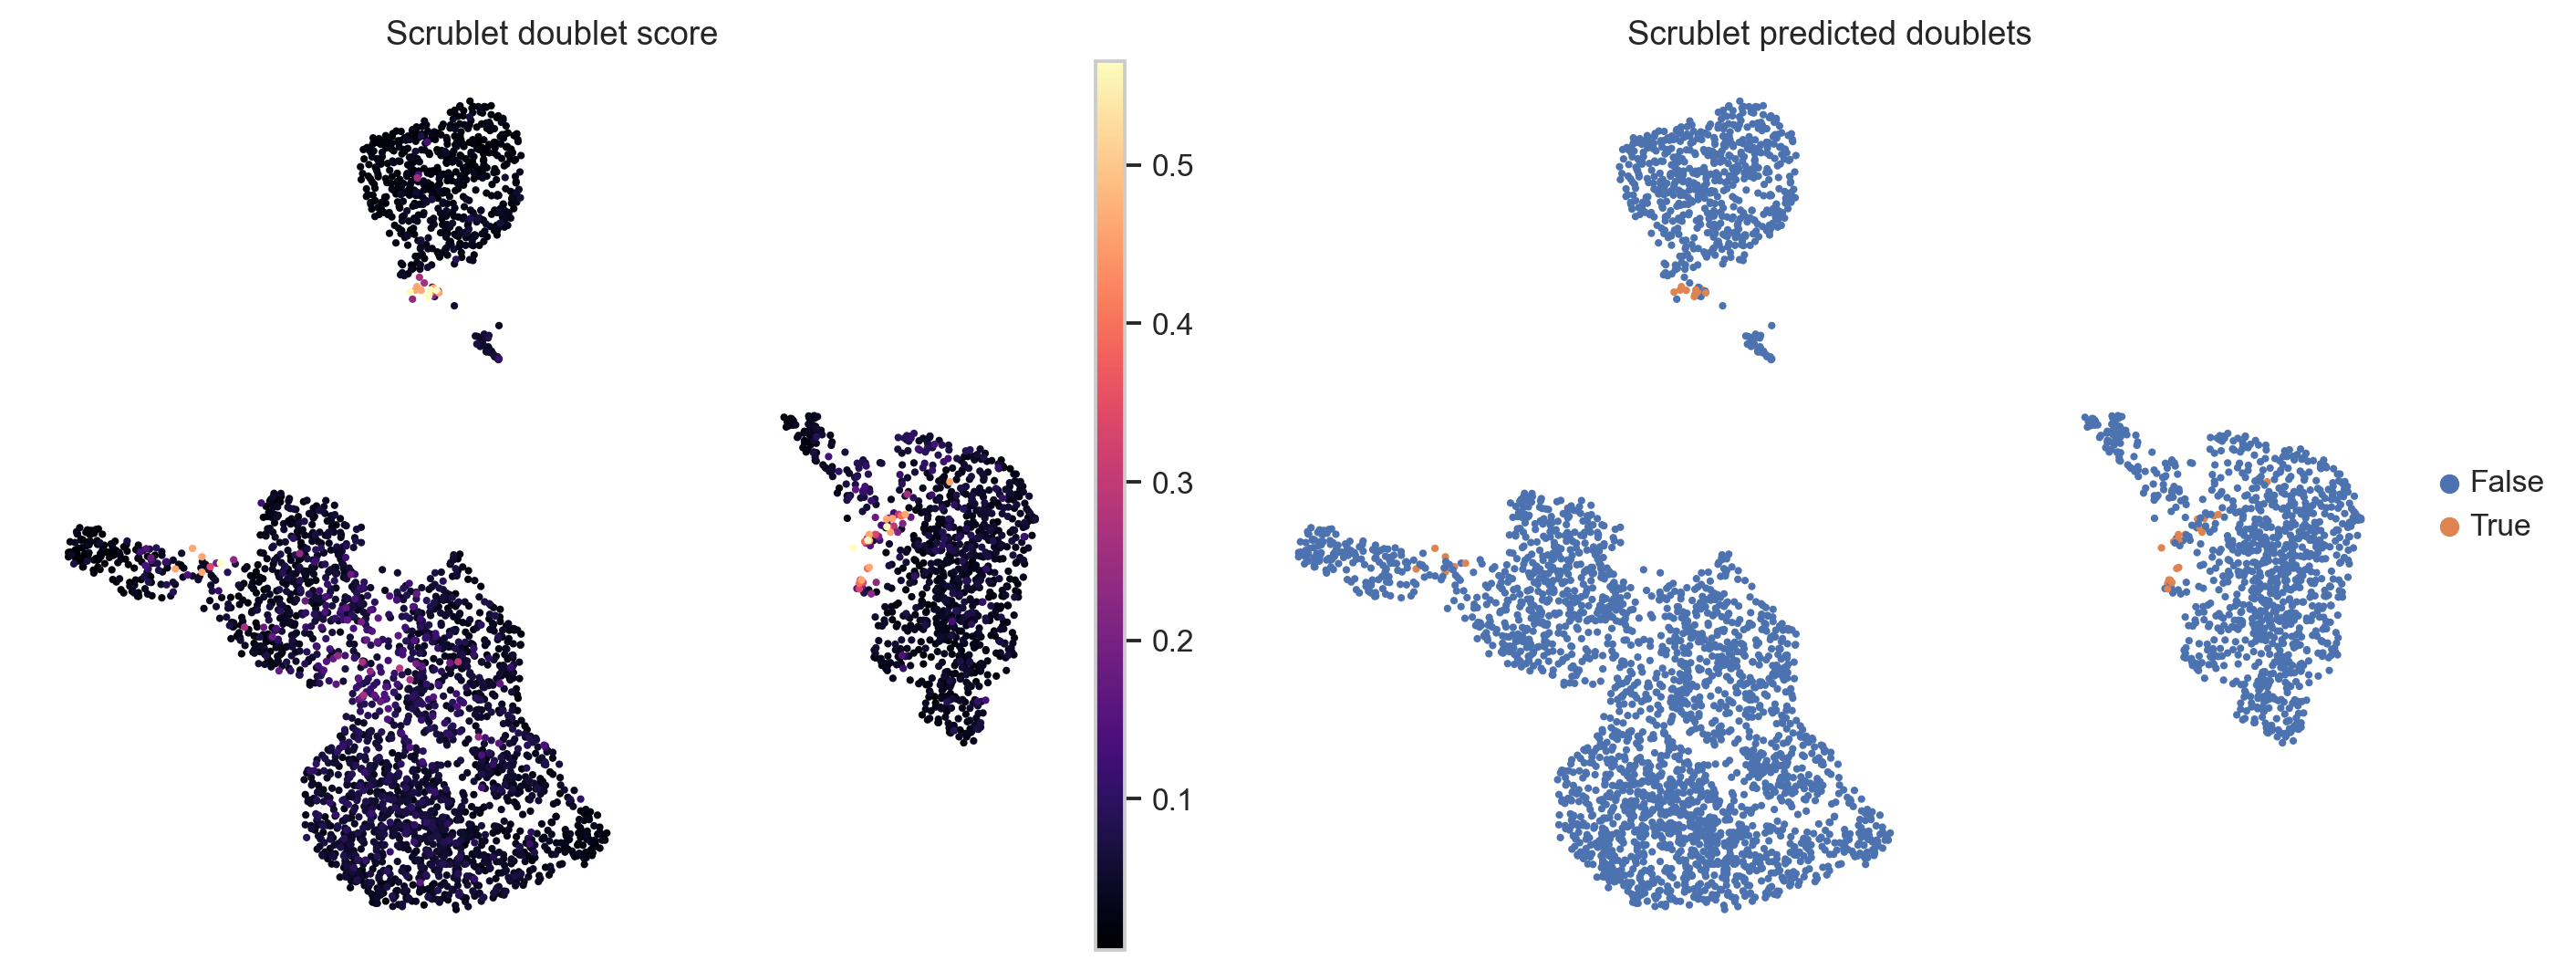

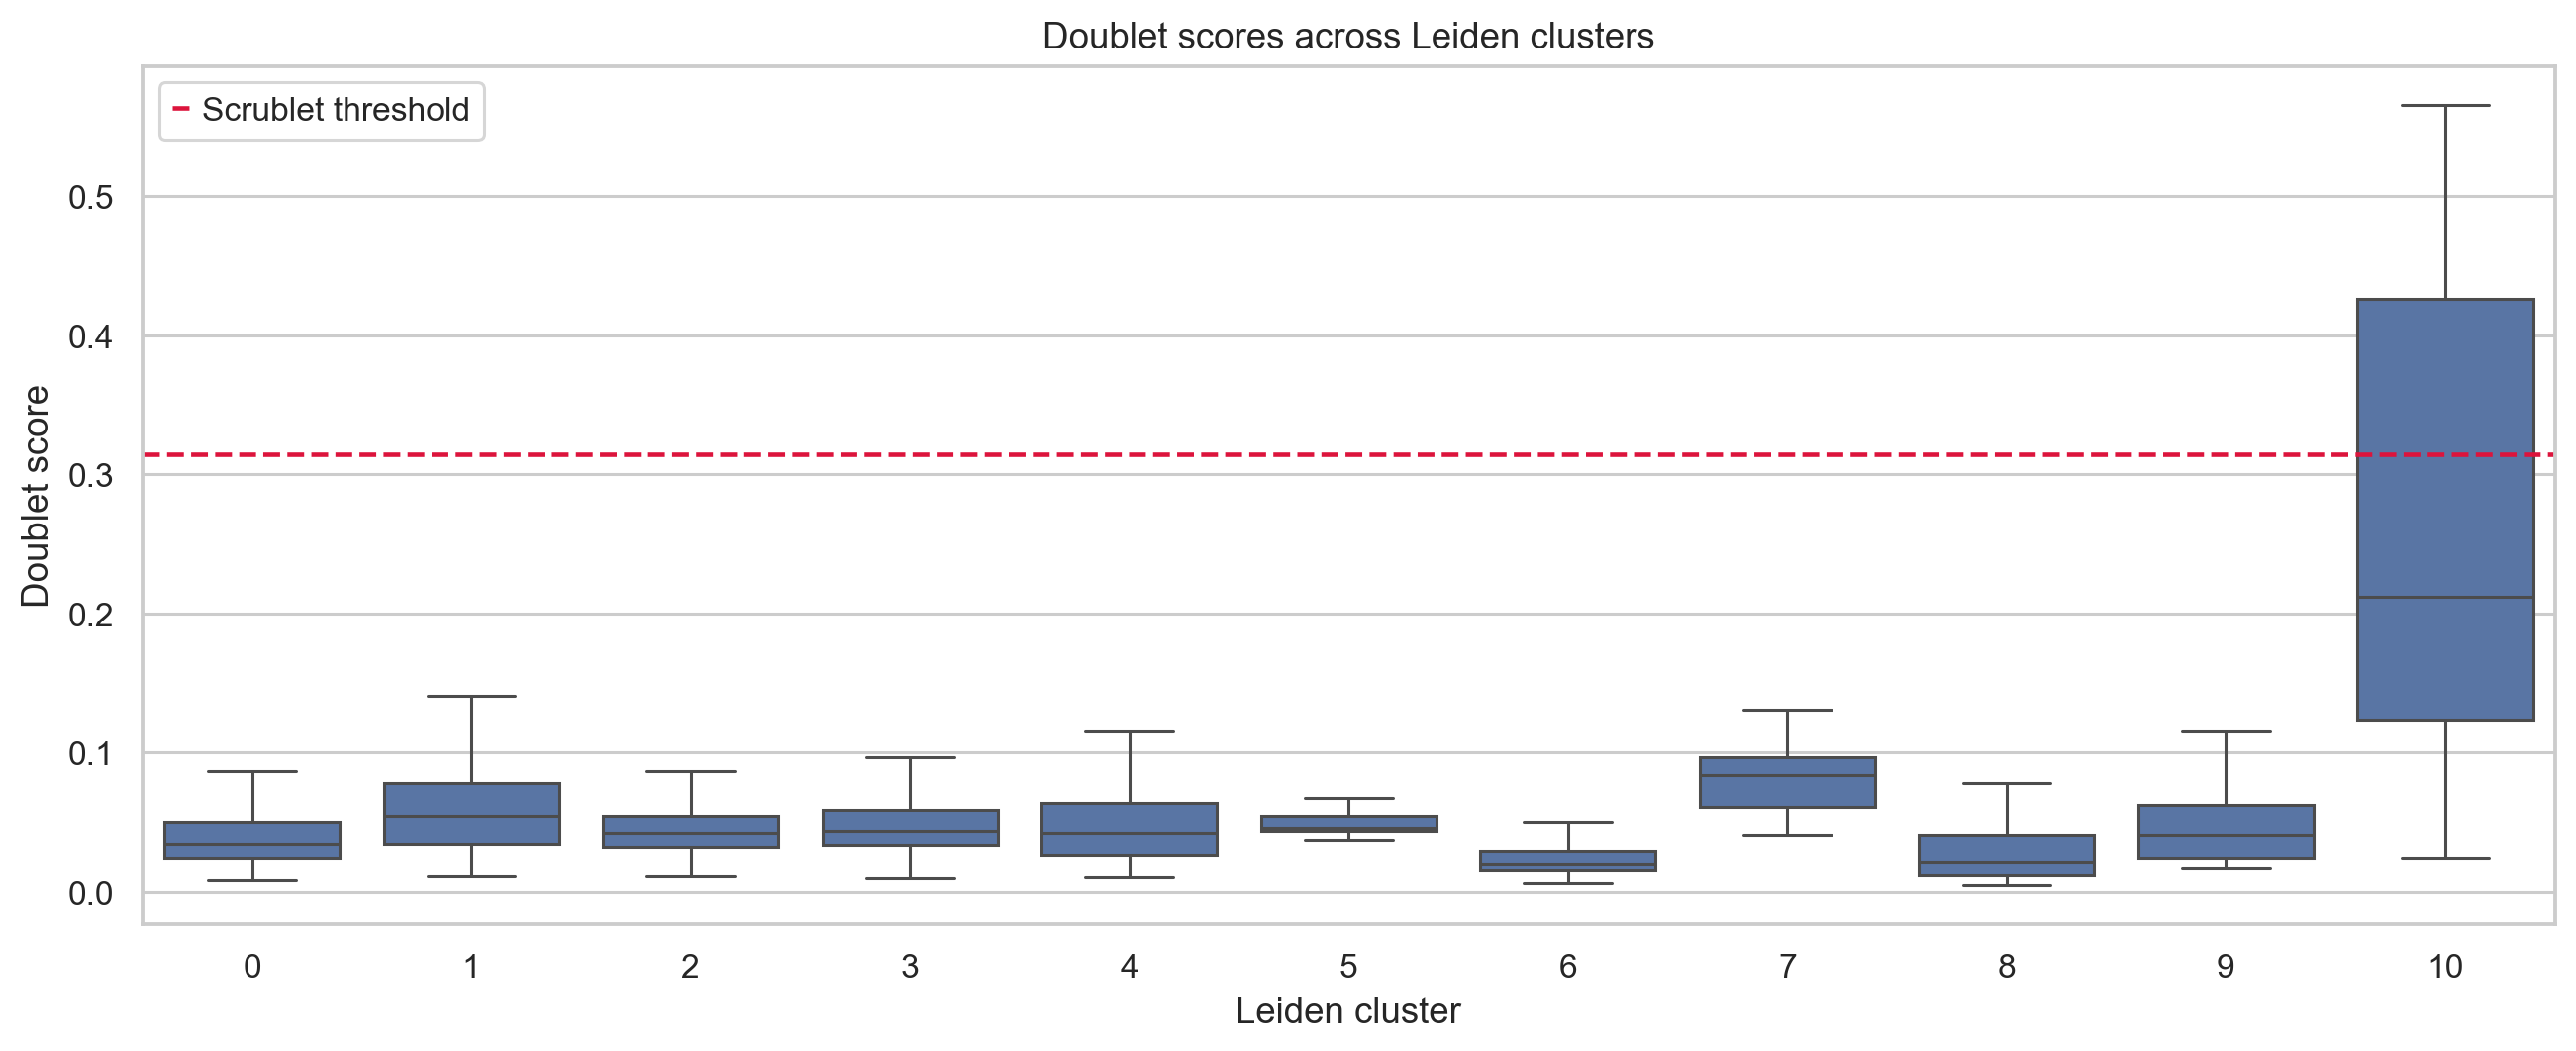

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(
    adata,
    color="doublet_score",
    color_map="magma",
    title="Scrublet doublet score",
    ax=axes[0],
    show=False,
)
sc.pl.umap(
    adata,
    color="predicted_doublet",
    title="Scrublet predicted doublets",
    ax=axes[1],
    show=False,
)
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_scrublet_umap.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=adata.obs.assign(leiden_string=adata.obs["leiden"].astype(str)),
    x="leiden_string",
    y="doublet_score",
    order=[str(cluster) for cluster in adata.obs["leiden"].cat.categories],
    showfliers=False,
)
plt.axhline(doublet_threshold, color="crimson", linestyle="--", label="Scrublet threshold")
plt.xlabel("Leiden cluster")
plt.ylabel("Doublet score")
plt.title("Doublet scores across Leiden clusters")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_doublet_scores_by_cluster.png", dpi=160, bbox_inches="tight")
plt.show()

In [17]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

LEIDEN_RESOLUTIONS = (0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0)
STABILITY_SEEDS = (7, 21, 84)
FOCUS_CLUSTERS = ("5", "7", "10")
SILHOUETTE_SAMPLE_SIZE = 2_000

base_labels = adata.obs["leiden"].astype(str).to_numpy()
X_cluster = adata.obsm["X_pca"][:, :pcs_used]
resolution_rows = []
focus_rows = []

def eta_squared(values, labels):
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    total_ss = np.square(values - values.mean()).sum()
    if total_ss == 0:
        return 0.0
    between_ss = sum(
        np.sum(labels == group) * np.square(values[labels == group].mean() - values.mean())
        for group in np.unique(labels)
    )
    return float(between_ss / total_ss)

for resolution in LEIDEN_RESOLUTIONS:
    key = f"leiden_sensitivity_{resolution:.1f}".replace(".", "_")
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=key,
        random_state=RANDOM_STATE,
        flavor="igraph",
        n_iterations=2,
        directed=False,
    )
    labels = adata.obs[key].astype(str).to_numpy()
    cluster_count = np.unique(labels).size
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, adata.n_obs)
    silhouette = silhouette_score(
        X_cluster,
        labels,
        sample_size=sample_size if sample_size < adata.n_obs else None,
        random_state=RANDOM_STATE,
    )

    repeat_aris = []
    for seed in STABILITY_SEEDS:
        repeat_key = f"_leiden_repeat_{resolution:.1f}_{seed}".replace(".", "_")
        sc.tl.leiden(
            adata,
            resolution=resolution,
            key_added=repeat_key,
            random_state=seed,
            flavor="igraph",
            n_iterations=2,
            directed=False,
        )
        repeat_aris.append(
            adjusted_rand_score(labels, adata.obs[repeat_key].astype(str).to_numpy())
        )
        del adata.obs[repeat_key]

    counts = pd.Series(labels).value_counts()
    qc_effects = [eta_squared(adata.obs[column], labels) for column in qc_columns]
    resolution_rows.append(
        {
            "resolution": resolution,
            "clusters": cluster_count,
            "silhouette": silhouette,
            "random_seed_stability_ari": np.mean(repeat_aris),
            "agreement_with_resolution_0_5_ari": adjusted_rand_score(base_labels, labels),
            "smallest_cluster_cells": int(counts.min()),
            "smallest_cluster_percent": 100 * counts.min() / adata.n_obs,
            "max_qc_eta_squared": max(qc_effects),
        }
    )

    for focus_cluster in FOCUS_CLUSTERS:
        focus_mask = base_labels == focus_cluster
        destination_counts = pd.Series(labels[focus_mask]).value_counts()
        destination = str(destination_counts.index[0])
        overlap = int(destination_counts.iloc[0])
        destination_size = int(np.sum(labels == destination))
        focus_rows.append(
            {
                "original_cluster": focus_cluster,
                "resolution": resolution,
                "destination_cluster": destination,
                "original_cells": int(focus_mask.sum()),
                "cells_staying_together": overlap,
                "cohesion": overlap / focus_mask.sum(),
                "destination_cluster_cells": destination_size,
                "exclusivity": overlap / destination_size,
            }
        )

resolution_diagnostics = pd.DataFrame(resolution_rows).set_index("resolution")
focus_stability = pd.DataFrame(focus_rows)
resolution_diagnostics.to_csv(TABLES / "pbmc4k_phase2_leiden_resolution_diagnostics.csv")
focus_stability.to_csv(TABLES / "pbmc4k_phase2_rare_cluster_stability.csv", index=False)

display(
    resolution_diagnostics.style.format(
        {
            "silhouette": "{:.3f}",
            "random_seed_stability_ari": "{:.3f}",
            "agreement_with_resolution_0_5_ari": "{:.3f}",
            "smallest_cluster_percent": "{:.2f}%",
            "max_qc_eta_squared": "{:.3f}",
        }
    )
)
display(
    focus_stability.style.format({"cohesion": "{:.1%}", "exclusivity": "{:.1%}"})
)

running Leiden clustering


    finished (0:00:00)


running Leiden clustering


    finished (0:00:00)


running Leiden clustering


...

    finished (0:00:00)


running Leiden clustering


    finished (0:00:00)


,clusters,silhouette,random_seed_stability_ari,agreement_with_resolution_0_5_ari,smallest_cluster_cells,smallest_cluster_percent,max_qc_eta_squared
resolution,,,,,,,
0.200000,8,0.361,0.863,0.869,33,0.79%,0.513
0.300000,8,0.333,0.975,0.926,33,0.79%,0.516
0.400000,10,0.314,0.963,0.900,34,0.82%,0.514
0.500000,11,0.271,0.863,1.000,34,0.82%,0.530
0.600000,12,0.271,0.835,0.840,34,0.82%,0.529
0.700000,13,0.274,0.921,0.831,34,0.82%,0.537
0.800000,16,0.218,0.807,0.675,14,0.34%,0.541
1.000000,18,0.215,0.843,0.690,17,0.41%,0.552


,original_cluster,resolution,destination_cluster,original_cells,cells_staying_together,cohesion,destination_cluster_cells,exclusivity
0,5,0.200000,4,34,33,97.1%,33,100.0%
1,7,0.200000,0,44,44,100.0%,944,4.7%
2,10,0.200000,0,35,35,100.0%,944,3.7%
3,5,0.300000,1,34,33,97.1%,33,100.0%
4,7,0.300000,0,44,44,100.0%,944,4.7%
5,10,0.300000,0,35,35,100.0%,944,3.7%
6,5,0.400000,5,34,34,100.0%,34,100.0%
7,7,0.400000,0,44,44,100.0%,944,4.7%
8,10,0.400000,0,35,35,100.0%,944,3.7%
9,5,0.500000,5,34,34,100.0%,34,100.0%


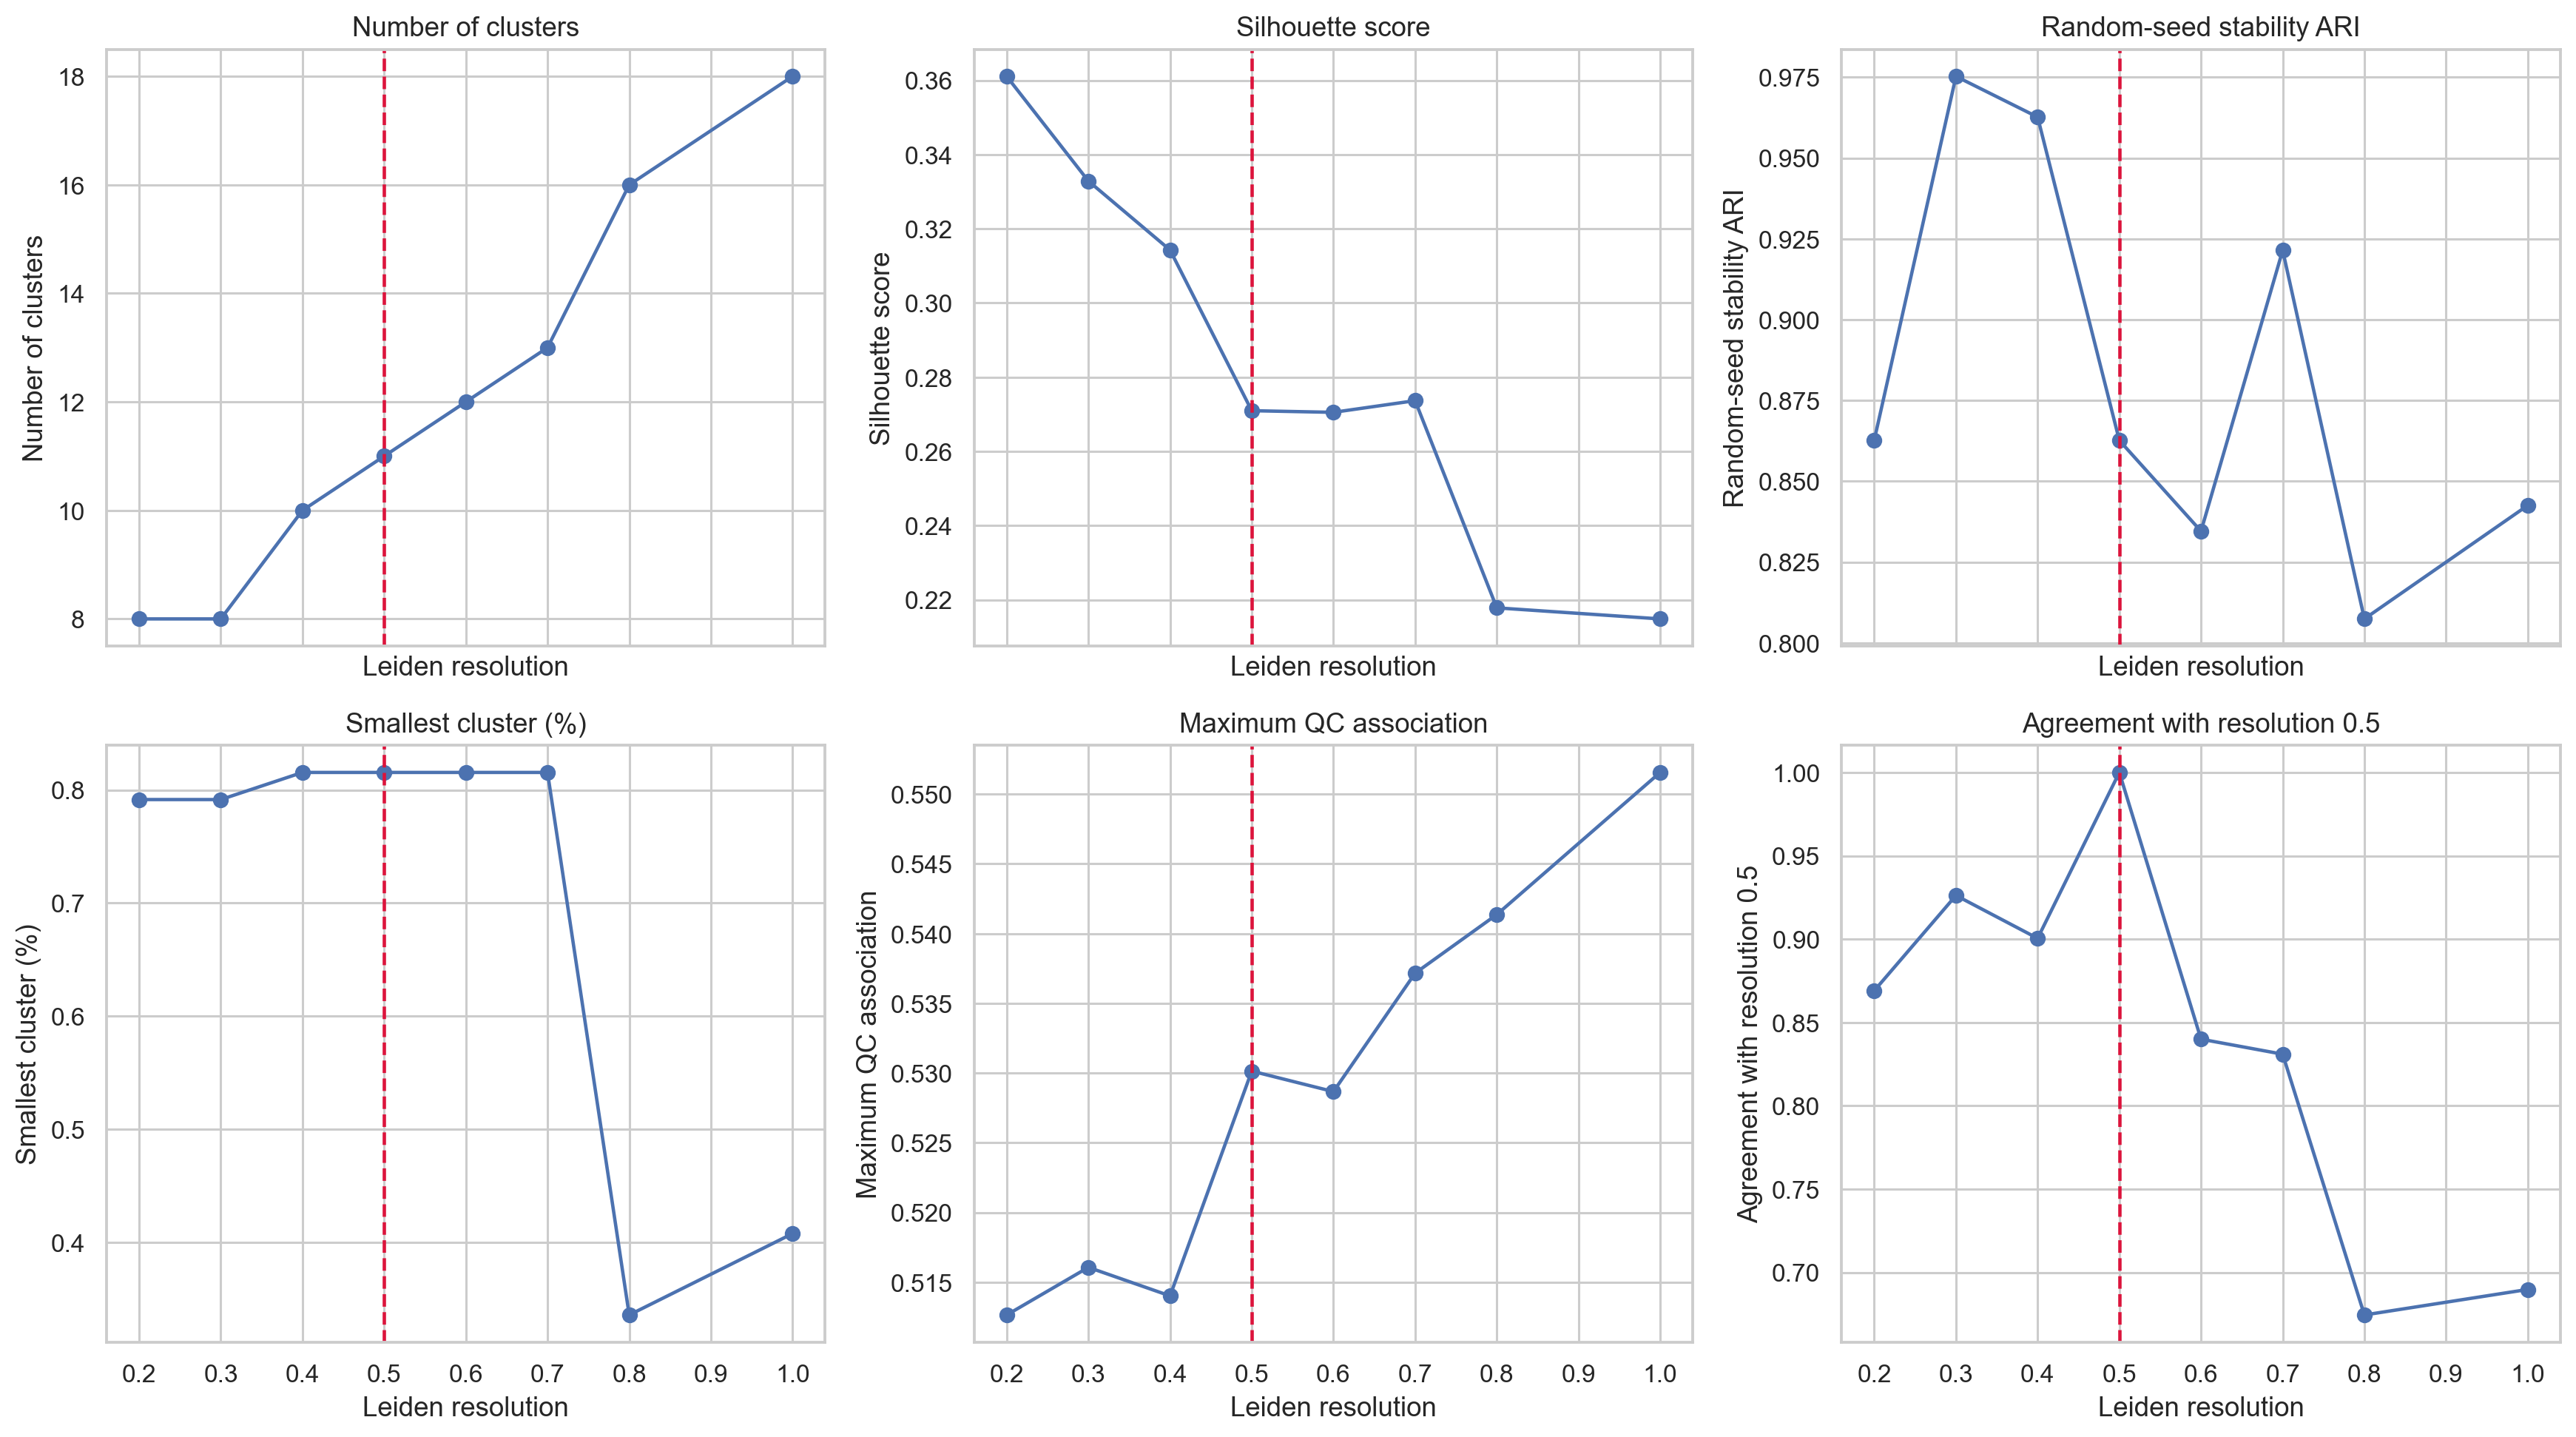

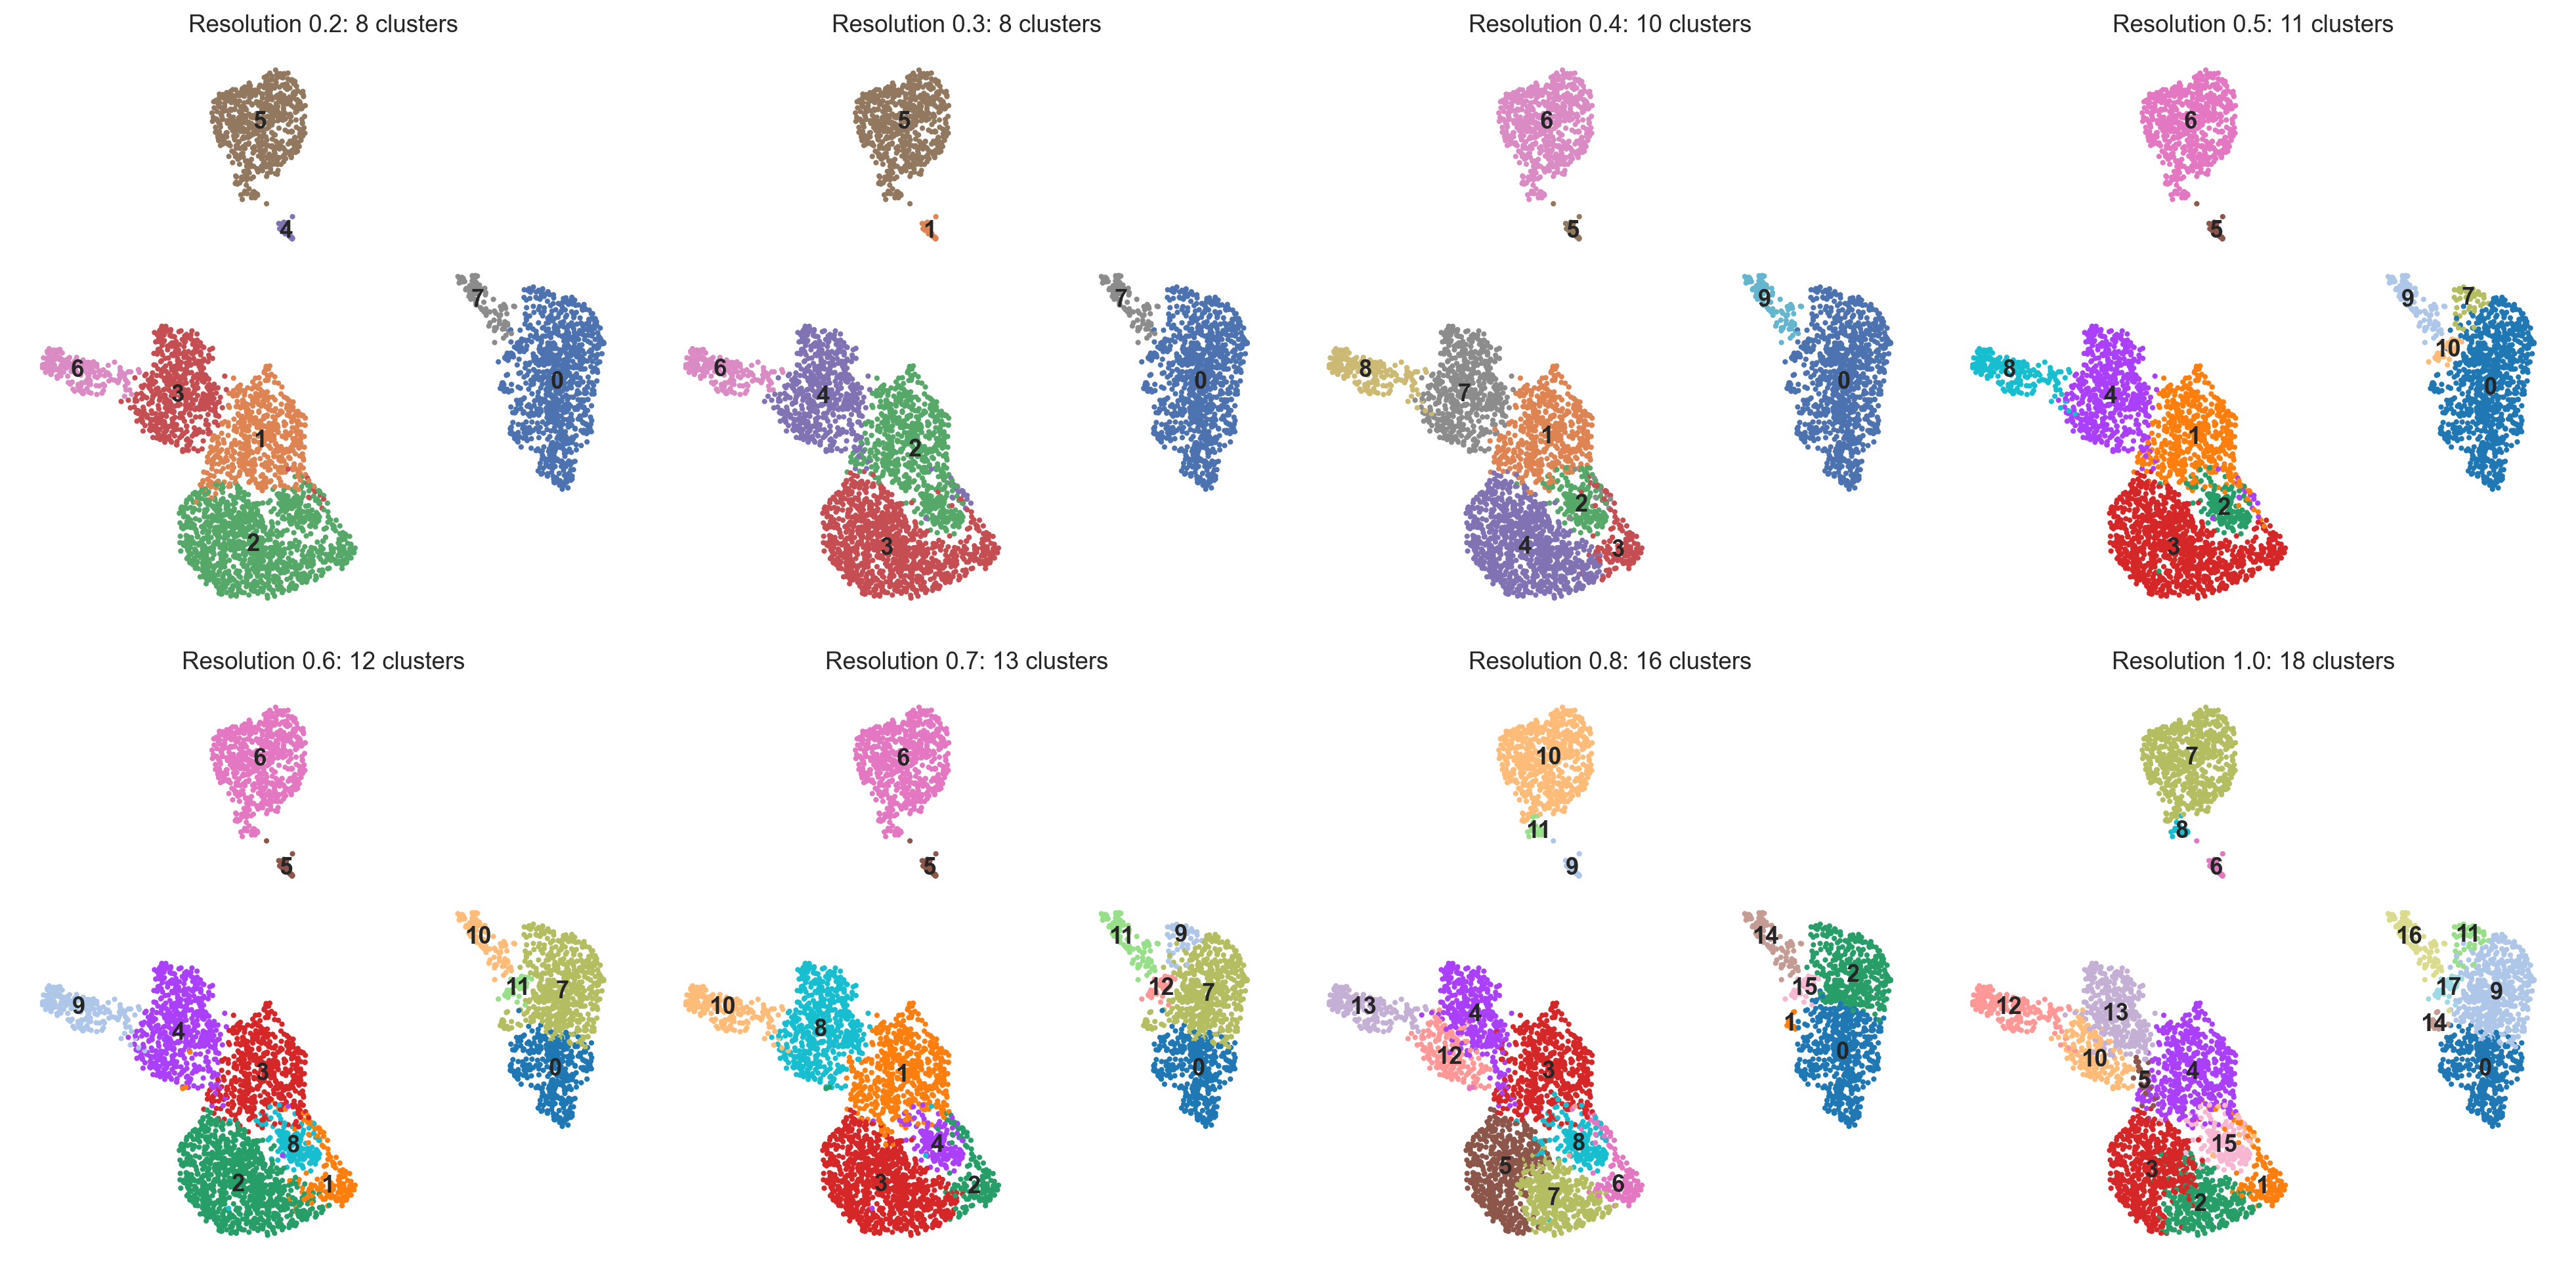

In [18]:
metric_panels = (
    ("clusters", "Number of clusters"),
    ("silhouette", "Silhouette score"),
    ("random_seed_stability_ari", "Random-seed stability ARI"),
    ("smallest_cluster_percent", "Smallest cluster (%)"),
    ("max_qc_eta_squared", "Maximum QC association"),
    ("agreement_with_resolution_0_5_ari", "Agreement with resolution 0.5"),
)
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for axis, (metric, title) in zip(axes.flat, metric_panels):
    axis.plot(resolution_diagnostics.index, resolution_diagnostics[metric], marker="o")
    axis.axvline(LEIDEN_RESOLUTION, color="crimson", linestyle="--")
    axis.set(title=title, xlabel="Leiden resolution", ylabel=title)
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_leiden_resolution_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for axis, resolution in zip(axes.flat, LEIDEN_RESOLUTIONS):
    key = f"leiden_sensitivity_{resolution:.1f}".replace(".", "_")
    sc.pl.umap(
        adata,
        color=key,
        legend_loc="on data",
        title=f"Resolution {resolution:.1f}: {adata.obs[key].nunique()} clusters",
        ax=axis,
        show=False,
    )
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase2_leiden_resolution_umaps.png", dpi=160, bbox_inches="tight")
plt.show()

In [19]:
marker_evidence = {
    "5": "LILRA4, GZMB, JCHAIN, IRF7, PLD4 (plasmacytoid dendritic program)",
    "7": "FCER1A, CD1C, CLEC10A, CST3, HLA-DRA (conventional dendritic program)",
    "10": "LYZ/LST1/S100 genes together with CD3D/NKG7 (conflicting myeloid and lymphoid programs)",
}
starting_recommendation = {
    "5": "retain as a rare pDC candidate if stability and doublet evidence remain acceptable",
    "7": "retain as a dendritic candidate only if doublet evidence is acceptable",
    "10": "flag as suspected doublets; do not use for annotation or model evaluation until resolved",
}

nearby = focus_stability[focus_stability["resolution"].between(0.3, 0.8)]
rare_cluster_review = pd.DataFrame(index=list(FOCUS_CLUSTERS))
rare_cluster_review.index.name = "cluster"
rare_cluster_review["cells"] = doublet_summary.loc[list(FOCUS_CLUSTERS), "cells"]
rare_cluster_review["predicted_doublets"] = doublet_summary.loc[
    list(FOCUS_CLUSTERS), "predicted_doublets"
]
rare_cluster_review["predicted_doublet_percent"] = doublet_summary.loc[
    list(FOCUS_CLUSTERS), "predicted_doublet_percent"
]
rare_cluster_review["median_doublet_score"] = doublet_summary.loc[
    list(FOCUS_CLUSTERS), "median_doublet_score"
]
rare_cluster_review["minimum_nearby_resolution_cohesion"] = (
    nearby.groupby("original_cluster")["cohesion"].min().reindex(rare_cluster_review.index)
)
rare_cluster_review["minimum_nearby_resolution_exclusivity"] = (
    nearby.groupby("original_cluster")["exclusivity"].min().reindex(rare_cluster_review.index)
)
rare_cluster_review["marker_evidence"] = pd.Series(marker_evidence)
rare_cluster_review["preliminary_recommendation"] = pd.Series(starting_recommendation)
rare_cluster_review.to_csv(TABLES / "pbmc4k_phase2_rare_cluster_review.csv")

display(
    rare_cluster_review.style.format(
        {
            "predicted_doublet_percent": "{:.1f}%",
            "median_doublet_score": "{:.3f}",
            "minimum_nearby_resolution_cohesion": "{:.1%}",
            "minimum_nearby_resolution_exclusivity": "{:.1%}",
        }
    )
)
print("No cells were removed. Review this evidence before changing the analysis population.")

,cells,predicted_doublets,predicted_doublet_percent,median_doublet_score,minimum_nearby_resolution_cohesion,minimum_nearby_resolution_exclusivity,marker_evidence,preliminary_recommendation
cluster,,,,,,,,
5,34,0,0.0%,0.045,97.1%,100.0%,"LILRA4, GZMB, JCHAIN, IRF7, PLD4 (plasmacytoid dendritic program)",retain as a rare pDC candidate if stability and doublet evidence remain acceptable
7,44,0,0.0%,0.084,100.0%,4.7%,"FCER1A, CD1C, CLEC10A, CST3, HLA-DRA (conventional dendritic program)",retain as a dendritic candidate only if doublet evidence is acceptable
10,35,13,37.1%,0.212,100.0%,3.7%,LYZ/LST1/S100 genes together with CD3D/NKG7 (conflicting myeloid and lymphoid programs),flag as suspected doublets; do not use for annotation or model evaluation until resolved


No cells were removed. Review this evidence before changing the analysis population.


In [20]:
adata.uns["rare_cluster_validation"] = {
    "focus_clusters": list(FOCUS_CLUSTERS),
    "scrublet_expected_doublet_rate": EXPECTED_DOUBLET_RATE,
    "scrublet_threshold": doublet_threshold,
    "leiden_resolutions_tested": list(LEIDEN_RESOLUTIONS),
    "stability_random_seeds": list(STABILITY_SEEDS),
    "cells_removed": 0,
}
adata.write_h5ad(OUTPUT, compression="gzip")
print("Saved doublet scores and sensitivity results in:", OUTPUT)
print("No cells were deleted and the original resolution-0.5 labels remain in adata.obs['leiden'].")

Saved doublet scores and sensitivity results in: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/processed/pbmc4k_phase2_clustered.h5ad
No cells were deleted and the original resolution-0.5 labels remain in adata.obs['leiden'].
